# Notebook 2 — Global Modelling with Temporal Features



## Cell 1 — Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from scipy.stats import randint, uniform
from xgboost import XGBRegressor

print('All imports successful.')

All imports successful.


## Cell 2 — Load Data

Loads seen_data.parquet saved by Notebook 1.

Each row = one 30-second bucket for one stock in one trading session.

- 20 buckets per time_id (seconds 0–599 split into 20 × 30s windows)
- Bucket 19 (the 19th input row) predicts bucket 20's realised volatility
- Bucket 20 itself is used only as a target and does not appear as an input row
  (its target_rv would be NaN and was dropped in preprocessing)

In [ ]:
seed = 3888
np.random.seed(seed)

# Load processed data 
seen_data = pd.read_parquet('seen_data.parquet')

with open('stock_split.json', 'r') as f:
    splits = json.load(f)

seen_stocks   = splits['seen_stocks']
unseen_stocks = splits['unseen_stocks']

print(f'Seen data shape : {seen_data.shape}')
print(f'Seen stocks     : {len(seen_stocks)}')
print(f'Unseen stocks   : {len(unseen_stocks)}')
print(f'Buckets present : {sorted(seen_data["bucket"].unique())}')
print(f'Columns         : {list(seen_data.columns)}')
print()


b19 = seen_data[seen_data['bucket'] == 19]
print(f'Bucket 19 rows         : {len(b19):,}')
print(f'Bucket 19 target NaNs  : {b19["target_rv"].isna().sum()}')
print('(Bucket 19 predicts bucket 20 RV — should have 0 NaNs)')
print()
seen_data.head()

Seen data shape : (2910553, 12)
Seen stocks     : 40
Unseen stocks   : 20
Buckets present : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Columns         : ['stock_id', 'time_id', 'bucket', 'wap_last', 'wap_mean', 'spread_mean', 'spread_max', 'log_return_sum', 'log_return_std', 'n_obs', 'realised_volatility', 'target_rv']

Bucket 19 rows         : 153,187
Bucket 19 target NaNs  : 0
(Bucket 19 predicts bucket 20 RV — should have 0 NaNs)



,stock_id,time_id,bucket,wap_last,wap_mean,spread_mean,spread_max,log_return_sum,log_return_std,n_obs,realised_volatility,target_rv
0,5,5,1,1.001802,1.001516,0.001219,0.002005,0.000479,0.000123,30,0.000670,0.001268
1,5,5,2,1.001797,1.001448,0.001110,0.001327,-0.000005,0.000235,30,0.001268,0.001828
2,5,5,3,1.001324,1.001776,0.001306,0.001598,-0.000473,0.000339,30,0.001828,0.001479
3,5,5,4,1.000361,1.000403,0.001481,0.001598,-0.000962,0.000273,30,0.001479,0.001766
4,5,5,5,1.000747,1.000877,0.001462,0.001652,0.000386,0.000328,30,0.001766,0.001483


## Cell 3 — Evaluation Metrics

- **RMSE**: raw error in same units as RV
- **RMSPE**: percentage error — comparable across stocks with different vol levels
- **QLIKE**: finance-standard loss — penalises underestimating volatility heavily

In [7]:
EPS = 1e-5

def _clean(y_true, y_pred):
    """Remove non-finite values and clip to EPS."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.maximum(y_true[mask], EPS), np.maximum(y_pred[mask], EPS)

def rmse(y_true, y_pred):
    y_true, y_pred = _clean(y_true, y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def rmspe(y_true, y_pred):
    """Root Mean Squared Percentage Error."""
    y_true, y_pred = _clean(y_true, y_pred)
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

def qlike(y_true, y_pred):
    """QLIKE — penalises underestimating volatility heavily."""
    y_true, y_pred = _clean(y_true, y_pred)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

def qlike_scorer(y_true, y_pred):
    """Negated QLIKE for sklearn (sklearn maximises, so we negate to minimise QLIKE)."""
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), EPS)
    ratio  = y_true / y_pred
    return -np.mean(ratio - np.log(ratio) - 1)

qlike_score = make_scorer(qlike_scorer)

def evaluate(model, X, y, label=''):
    """Predict and return all three metrics as a dict."""
    y_pred = np.maximum(model.predict(X), EPS)
    return {
        'label': label,
        'rmse' : rmse(y, y_pred),
        'rmspe': rmspe(y, y_pred),
        'qlike': qlike(y, y_pred),
    }

print('Metrics defined: rmse, rmspe, qlike, evaluate()')

Metrics defined: rmse, rmspe, qlike, evaluate()


## Cell 4 — Train / Val / Test Split

Split is at the **time_id level** — every seen stock appears in all three splits,
but different trading sessions go to different splits.


In [ ]:
# Base features 

base_features = [
    'wap_mean', 'wap_last',
    'spread_mean', 'spread_max',
    'log_return_sum', 'log_return_std',
    'realised_volatility',   # ← implicit lag 1
]
target = 'target_rv'

# Split time ids

all_tids = seen_data['time_id'].unique()
np.random.seed(seed)
all_tids = all_tids.copy()
np.random.shuffle(all_tids)

n_total  = len(all_tids)
n_train  = int(0.70 * n_total)
n_val    = int(0.15 * n_total)

train_tids = set(all_tids[:n_train])
val_tids   = set(all_tids[n_train : n_train + n_val])
test_tids  = set(all_tids[n_train + n_val:])

print(f'Total time_ids : {n_total}')
print(f'Train time_ids : {len(train_tids)}  ({100*len(train_tids)/n_total:.0f}%)')
print(f'Val time_ids   : {len(val_tids)}   ({100*len(val_tids)/n_total:.0f}%)')
print(f'Test time_ids  : {len(test_tids)}   ({100*len(test_tids)/n_total:.0f}%)')


def make_split_df(data, tid_set):
    """
    Filter to the given time_ids and sort by (stock_id, time_id, bucket)
    so bucket ordering within each session is always preserved.
    This is critical for lag/rolling features computed downstream.
    """
    df = data[data['time_id'].isin(tid_set)].copy()
    df = df.sort_values(['stock_id', 'time_id', 'bucket']).reset_index(drop=True)
    return df

train_df = make_split_df(seen_data, train_tids)
val_df   = make_split_df(seen_data, val_tids)
test_df  = make_split_df(seen_data, test_tids)


train_df = train_df.dropna(subset=base_features + [target]).reset_index(drop=True)
val_df   = val_df.dropna(subset=base_features + [target]).reset_index(drop=True)
test_df  = test_df.dropna(subset=base_features + [target]).reset_index(drop=True)

print(f'\nBase split row counts:')
print(f'  Train : {len(train_df):,}')
print(f'  Val   : {len(val_df):,}')
print(f'  Test  : {len(test_df):,}')


X_train_base = train_df[base_features].values
y_train_base = train_df[target].values

X_val_base   = val_df[base_features].values
y_val_base   = val_df[target].values

X_test_base  = test_df[base_features].values
y_test_base  = test_df[target].values


X_tune_base    = np.vstack([X_train_base, X_val_base])
y_tune_base    = np.hstack([y_train_base, y_val_base])
split_idx_base = np.array([-1]*len(X_train_base) + [0]*len(X_val_base))
ps_base        = PredefinedSplit(split_idx_base)

print(f'\nBase features    : {len(base_features)}')
print(f'Tuning pool      : {len(X_tune_base):,} rows')
print('Base split ready.')

Total time_ids : 3830
Train time_ids : 2681  (70%)
Val time_ids   : 574   (15%)
Test time_ids  : 575   (15%)

Base split row counts:
  Train : 2,037,370
  Val   : 436,183
  Test  : 437,000

Base features    : 7
Tuning pool      : 2,473,553 rows
Base split ready.


## Cell 5 — Temporal Feature Engineering

Three horizons of memory, computed **after** the train/val/test split.
All features are grouped by `(stock_id, time_id)` — lag/rolling features
never cross session boundaries.


In [ ]:
def add_temporal_features(df):
    """
    Add short, medium, and long-term temporal features.

    All features are computed within (stock_id, time_id) groups so
    they never cross session boundaries.

    Lag naming convention — relative to the PREDICTION TARGET:
        realised_volatility in each row = lag 1 (already in base features)
        rv_lag2 = 2 buckets before target → shift(1) on realised_volatility
        rv_lag3 = 3 buckets before target → shift(2)
        rv_lag5 = 5 buckets before target → shift(4)
        rv_lag10= 10 buckets before target→ shift(9)

    Rolling windows use the current row's rv as the most recent value
    (no internal shift needed — realised_volatility IS the lag 1 value).

    Returns
    -------
    df_short  : DataFrame with short features added, early NaN rows dropped
    df_medium : DataFrame with short+medium features added, early NaN rows dropped
    df_long   : DataFrame with all features added, early NaN rows dropped
    short_features, medium_features, long_features : feature name lists
    """
    df = df.copy().sort_values(['stock_id', 'time_id', 'bucket']).reset_index(drop=True)
    grp = df.groupby(['stock_id', 'time_id'])

 # Short term

    df['rv_lag2']     = grp['realised_volatility'].shift(1)
    df['rv_lag3']     = grp['realised_volatility'].shift(2)
    df['spread_lag2'] = grp['spread_mean'].shift(1)
    df['spread_lag3'] = grp['spread_mean'].shift(2)
    df['logret_lag2'] = grp['log_return_sum'].shift(1)

    df['rv_delta'] = grp['realised_volatility'].transform(lambda x: x.diff())

    df['rv_rollmean3']     = grp['realised_volatility'].transform(
        lambda x: x.rolling(3, min_periods=2).mean()
    )
    df['spread_rollmean3'] = grp['spread_mean'].transform(
        lambda x: x.rolling(3, min_periods=2).mean()
    )

    short_features = [
        'rv_lag2', 'rv_lag3',
        'spread_lag2', 'spread_lag3',
        'logret_lag2',
        'rv_delta',
        'rv_rollmean3', 'spread_rollmean3',
    ]

    # Medium

    df['rv_lag5']     = grp['realised_volatility'].shift(4)
    df['spread_lag5'] = grp['spread_mean'].shift(4)
    df['logret_lag5'] = grp['log_return_sum'].shift(4)

    
    df['rv_momentum5'] = df['realised_volatility'] - df['rv_lag5']

    df['rv_rollmean5']     = grp['realised_volatility'].transform(
        lambda x: x.rolling(5, min_periods=3).mean()
    )
    df['rv_rollstd5']      = grp['realised_volatility'].transform(
        lambda x: x.rolling(5, min_periods=3).std()
    )
    df['spread_rollmean5'] = grp['spread_mean'].transform(
        lambda x: x.rolling(5, min_periods=3).mean()
    )

    df['rv_ratio5']      = df['realised_volatility'] / (df['rv_rollmean5'] + EPS)
    df['rv_above_mean5'] = (df['realised_volatility'] > df['rv_rollmean5']).astype(int)

    medium_features = [
        'rv_lag5', 'spread_lag5', 'logret_lag5',
        'rv_momentum5',
        'rv_rollmean5', 'rv_rollstd5', 'spread_rollmean5',
        'rv_ratio5', 'rv_above_mean5',
    ]

    # Long term
    df['rv_lag10']     = grp['realised_volatility'].shift(9)
    df['spread_lag10'] = grp['spread_mean'].shift(9)


    df['rv_momentum10'] = df['realised_volatility'] - df['rv_lag10']

   
    df['rv_rollmean10']     = grp['realised_volatility'].transform(
        lambda x: x.rolling(10, min_periods=6).mean()
    )
    df['rv_rollstd10']      = grp['realised_volatility'].transform(
        lambda x: x.rolling(10, min_periods=6).std()
    )
    df['spread_rollmean10'] = grp['spread_mean'].transform(
        lambda x: x.rolling(10, min_periods=6).mean()
    )


    df['rv_ratio10']      = df['realised_volatility'] / (df['rv_rollmean10'] + EPS)
    df['rv_above_mean10'] = (df['realised_volatility'] > df['rv_rollmean10']).astype(int)

    long_features = [
        'rv_lag10', 'spread_lag10',
        'rv_momentum10',
        'rv_rollmean10', 'rv_rollstd10', 'spread_rollmean10',
        'rv_ratio10', 'rv_above_mean10',
    ]


    df_short  = df.dropna(subset=short_features).reset_index(drop=True)
    df_medium = df.dropna(subset=short_features + medium_features).reset_index(drop=True)
    df_long   = df.dropna(subset=short_features + medium_features + long_features).reset_index(drop=True)

    return df_short, df_medium, df_long, short_features, medium_features, long_features



print('Computing temporal features...')

train_short, train_medium, train_long, short_f, medium_f, long_f = add_temporal_features(train_df)
val_short,   val_medium,   val_long,   _,       _,        _      = add_temporal_features(val_df)
test_short,  test_medium,  test_long,  _,       _,        _      = add_temporal_features(test_df)

features_short  = base_features + short_f
features_medium = base_features + short_f + medium_f
features_long   = base_features + short_f + medium_f + long_f

print(f'\nFeature counts:')
print(f'  Base only : {len(base_features):>3} features')
print(f'  + Short   : {len(features_short):>3} features  (lags 2-3, delta, rollmean3)')
print(f'  + Medium  : {len(features_medium):>3} features  (+ lag 5, momentum, rollmean5)')
print(f'  + Long    : {len(features_long):>3} features  (+ lag 10, rollmean10)')

print(f'\nRow counts after dropping early-bucket NaNs:')
print(f'  {"Split":<8} {"Base":>8} {"Short":>8} {"Medium":>8} {"Long":>8}')
print(f'  {"-"*44}')
print(f'  {"Train":<8} {len(train_df):>8,} {len(train_short):>8,} {len(train_medium):>8,} {len(train_long):>8,}')
print(f'  {"Val":<8} {len(val_df):>8,} {len(val_short):>8,} {len(val_medium):>8,} {len(val_long):>8,}')
print(f'  {"Test":<8} {len(test_df):>8,} {len(test_short):>8,} {len(test_medium):>8,} {len(test_long):>8,}')


def make_Xy(df, feat_cols):
    return df[feat_cols].values, df[target].values

X_train_s, y_train_s = make_Xy(train_short,  features_short)
X_val_s,   y_val_s   = make_Xy(val_short,    features_short)
X_test_s,  y_test_s  = make_Xy(test_short,   features_short)

X_train_m, y_train_m = make_Xy(train_medium, features_medium)
X_val_m,   y_val_m   = make_Xy(val_medium,   features_medium)
X_test_m,  y_test_m  = make_Xy(test_medium,  features_medium)

X_train_l, y_train_l = make_Xy(train_long,   features_long)
X_val_l,   y_val_l   = make_Xy(val_long,     features_long)
X_test_l,  y_test_l  = make_Xy(test_long,    features_long)


def make_ps(X_tr, X_v, y_tr, y_v):
    X_tune = np.vstack([X_tr, X_v])
    y_tune = np.hstack([y_tr, y_v])
    idx    = np.array([-1] * len(X_tr) + [0] * len(X_v))
    return X_tune, y_tune, PredefinedSplit(idx)

X_tune_s, y_tune_s, ps_s = make_ps(X_train_s, X_val_s, y_train_s, y_val_s)
X_tune_m, y_tune_m, ps_m = make_ps(X_train_m, X_val_m, y_train_m, y_val_m)
X_tune_l, y_tune_l, ps_l = make_ps(X_train_l, X_val_l, y_train_l, y_val_l)

print('\nAll temporal arrays and PredefinedSplits ready.')

Computing temporal features...

Feature counts:
  Base only :   7 features
  + Short   :  15 features  (lags 2-3, delta, rollmean3)
  + Medium  :  24 features  (+ lag 5, momentum, rollmean5)
  + Long    :  32 features  (+ lag 10, rollmean10)

Row counts after dropping early-bucket NaNs:
  Split        Base    Short   Medium     Long
  --------------------------------------------
  Train    2,037,370 1,822,910 1,608,450 1,072,300
  Val       436,183  390,269  344,355  229,570
  Test      437,000  391,000  345,000  230,000

All temporal arrays and PredefinedSplits ready.


## Cell 6 — Sanity Check: Inspect One Time_ID

Verify that temporal features are computed correctly.


Stock 5 | Time ID 5
Buckets in this time_id (long model): [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
(Buckets 1-9 dropped because lag10 requires 10 prior buckets)

── Core columns ──
 bucket  realised_volatility  target_rv
     10             0.000745   0.000778
     11             0.000778   0.000507
     12             0.000507   0.000081
     13             0.000081   0.001872
     14             0.001872   0.000875
     15             0.000875   0.000288
     16             0.000288   0.000506
     17             0.000506   0.001648
     18             0.001648   0.000906
     19             0.000906   0.000829

── Short temporal features ──
 bucket  realised_volatility  rv_lag2  rv_lag3  rv_delta  rv_rollmean3
     10             0.000745 0.000783 0.001181 -0.000039      0.000903
     11             0.000778 0.000745 0.000783  0.000034      0.000769
     12             0.000507 0.000778 0.000745 -0.000271      0.000677
     13             0.000081 0.000507 0.000778 -0.000426      0.

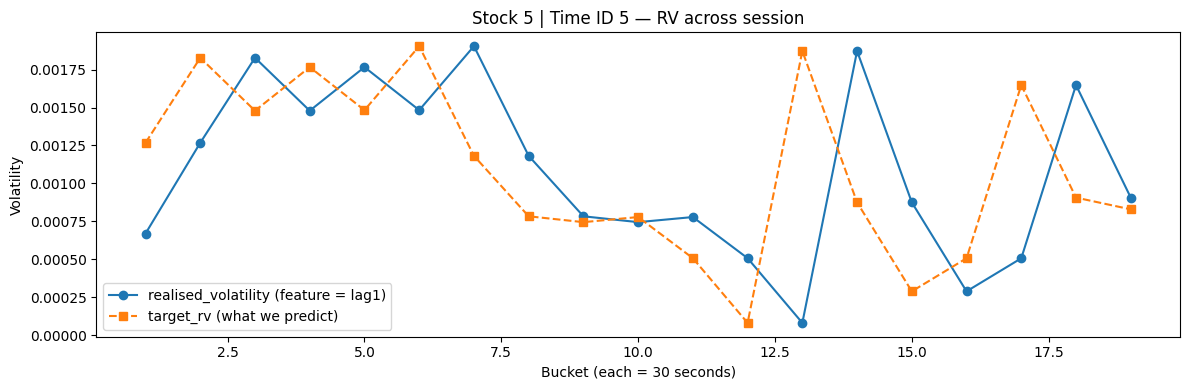

In [ ]:
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


inspect_stock = seen_stocks[0]
inspect_tid   = train_long[
    train_long['stock_id'] == inspect_stock
]['time_id'].iloc[0]

example = train_long[
    (train_long['stock_id'] == inspect_stock) &
    (train_long['time_id']  == inspect_tid)
].sort_values('bucket').reset_index(drop=True)

print(f'Stock {inspect_stock} | Time ID {inspect_tid}')
print(f'Buckets in this time_id (long model): {example["bucket"].tolist()}')
print(f'(Buckets 1-9 dropped because lag10 requires 10 prior buckets)')
print()


print('── Core columns ──')
print(example[[
    'bucket', 'realised_volatility', 'target_rv'
]].to_string(index=False))

print()
print('── Short temporal features ──')
print(example[[
    'bucket', 'realised_volatility',
    'rv_lag2', 'rv_lag3',
    'rv_delta', 'rv_rollmean3'
]].to_string(index=False))

print()
print('── Medium temporal features ──')
print(example[[
    'bucket', 'realised_volatility',
    'rv_lag5', 'rv_momentum5',
    'rv_rollmean5', 'rv_rollstd5', 'rv_ratio5'
]].to_string(index=False))

print()
print('── Long temporal features ──')
print(example[[
    'bucket', 'realised_volatility',
    'rv_lag10', 'rv_momentum10',
    'rv_rollmean10', 'rv_rollstd10', 'rv_ratio10'
]].to_string(index=False))


full_example = seen_data[
    (seen_data['stock_id'] == inspect_stock) &
    (seen_data['time_id']  == inspect_tid)
].sort_values('bucket')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(full_example['bucket'], full_example['realised_volatility'],
        marker='o', label='realised_volatility (feature = lag1)')
ax.plot(full_example['bucket'], full_example['target_rv'],
        marker='s', linestyle='--', label='target_rv (what we predict)')
ax.set_xlabel('Bucket (each = 30 seconds)')
ax.set_ylabel('Volatility')
ax.set_title(f'Stock {inspect_stock} | Time ID {inspect_tid} — RV across session')
ax.legend()
plt.tight_layout()
plt.show()

# Linear Regression
## Cell 7 — Linear Regression (Base Features)

Baseline: 7 features, 1 bucket of implicit memory (realised_volatility = lag1).
No hyperparameters to tune.

In [ ]:
results = {}  

lr_base = LinearRegression()
lr_base.fit(X_train_base, y_train_base)

res = evaluate(lr_base, X_test_base, y_test_base, 'LR Base')
results['LR Base'] = res

print('── Linear Regression (Base) — Test Results ──')
print(f'Features : {len(base_features)}')
print(f'RMSE     : {res["rmse"]:.6f}')
print(f'RMSPE    : {res["rmspe"]:.6f}')
print(f'QLIKE    : {res["qlike"]:.6f}')


coef_df = pd.DataFrame({
    'Feature':     base_features,
    'Coefficient': lr_base.coef_,
}).sort_values('Coefficient', key=abs, ascending=False)
print(f'\nCoefficients (intercept={lr_base.intercept_:.6f}):')
print(coef_df.to_string(index=False))

── Linear Regression (Base) — Test Results ──
Features : 7
RMSE     : 0.000659
RMSPE    : 12.814791
QLIKE    : 0.217463

Coefficients (intercept=0.003421):
            Feature  Coefficient
         spread_max     0.299041
realised_volatility     0.239285
        spread_mean     0.218525
     log_return_std     0.044132
           wap_mean    -0.001661
           wap_last    -0.001543
     log_return_sum     0.000375


## Cell 8 — Linear Regression (Temporal Features)

Three variants: short, medium, long memory.
Comparing coefficients shows which time horizon the model finds most useful.

In [12]:
for label, X_tr, y_tr, X_te, y_te, feats in [
    ('LR Short',  X_train_s, y_train_s, X_test_s, y_test_s, features_short),
    ('LR Medium', X_train_m, y_train_m, X_test_m, y_test_m, features_medium),
    ('LR Long',   X_train_l, y_train_l, X_test_l, y_test_l, features_long),
]:
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    res = evaluate(model, X_te, y_te, label)
    results[label] = res

    print(f'── {label} ──')
    print(f'Features : {len(feats)}')
    print(f'Test rows: {len(X_te):,}')
    print(f'RMSE     : {res["rmse"]:.6f}')
    print(f'RMSPE    : {res["rmspe"]:.6f}')
    print(f'QLIKE    : {res["qlike"]:.6f}')

    coef_df = pd.DataFrame({
        'Feature':     feats,
        'Coefficient': model.coef_,
    }).sort_values('Coefficient', key=abs, ascending=False)
    print('Top 10 features by absolute coefficient:')
    print(coef_df.head(10).to_string(index=False))
    print()
    if label == 'LR Short':  lr_short_model  = model
    if label == 'LR Medium': lr_medium_model = model
    if label == 'LR Long':   lr_long_model   = model

── LR Short ──
Features : 15
Test rows: 391,000
RMSE     : 0.000606
RMSPE    : 11.363320
QLIKE    : 0.190087
Top 10 features by absolute coefficient:
            Feature   Coefficient
realised_volatility  54669.757184
            rv_lag2 -54666.917990
           rv_delta -54666.802135
     log_return_std    -16.191965
       rv_rollmean3      0.900612
         spread_max      0.162622
            rv_lag3     -0.137353
        spread_lag3      0.073361
        spread_lag2     -0.037765
   spread_rollmean3      0.015535

── LR Medium ──
Features : 24
Test rows: 345,000
RMSE     : 0.000584
RMSPE    : 11.071077
QLIKE    : 0.184700
Top 10 features by absolute coefficient:
            Feature  Coefficient
     log_return_std   -14.291896
realised_volatility     1.263106
           rv_delta     0.706235
       rv_momentum5     0.632672
            rv_lag5     0.630435
            rv_lag2     0.556871
       rv_rollmean3     0.546731
       rv_rollmean5     0.530352
            rv_lag3    -0.1

# Lasso
## Cell 9 — Lasso (Base Features)

Lasso adds L1 regularisation — shrinks less useful coefficients to zero.
Useful for automatic feature selection. Scaled with StandardScaler.
Alpha tuned via RandomizedSearchCV on the validation set.

In [ ]:
lasso_pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  TransformedTargetRegressor(
        regressor=Lasso(max_iter=50000, random_state=seed),
        transformer=StandardScaler(),
    )),
])

search_lasso_base = RandomizedSearchCV(
    lasso_pipe_base,
    param_distributions={'lasso__regressor__alpha': uniform(1e-4, 1.0)},
    n_iter=80,
    scoring=qlike_score,
    cv=ps_base,
    refit=False,
    random_state=seed,
    verbose=0,
)

print('Tuning Lasso (base)...')
search_lasso_base.fit(X_tune_base, y_tune_base)
best_alpha_base = search_lasso_base.best_params_['lasso__regressor__alpha']
print(f'Best alpha : {best_alpha_base:.6f}')
print(f'Best val QLIKE : {-search_lasso_base.best_score_:.6f}')


lasso_final_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  TransformedTargetRegressor(
        regressor=Lasso(alpha=best_alpha_base, max_iter=50000, random_state=seed),
        transformer=StandardScaler(),
    )),
])
lasso_final_base.fit(X_train_base, y_train_base)

res = evaluate(lasso_final_base, X_test_base, y_test_base, 'Lasso Base')
results['Lasso Base'] = res

print(f'\n── Lasso (Base) — Test Results ──')
print(f'RMSE  : {res["rmse"]:.6f}')
print(f'RMSPE : {res["rmspe"]:.6f}')
print(f'QLIKE : {res["qlike"]:.6f}')


coefs = lasso_final_base.named_steps['lasso'].regressor_.coef_
coef_df = pd.DataFrame({
    'Feature':     base_features,
    'Coefficient': coefs,
    'Selected':    coefs != 0,
}).sort_values('Coefficient', key=abs, ascending=False)
print(f'\nFeatures retained: {(coefs != 0).sum()}/{len(base_features)}')
print(coef_df[['Feature', 'Coefficient', 'Selected']].to_string(index=False))

Tuning Lasso (base)...


Best alpha : 0.016407
Best val QLIKE : 0.208551

── Lasso (Base) — Test Results ──
RMSE  : 0.000650
RMSPE : 11.750069
QLIKE : 0.211676

Features retained: 3/7
            Feature  Coefficient  Selected
realised_volatility     0.392486      True
         spread_max     0.298878      True
        spread_mean     0.086249      True
           wap_mean    -0.000000     False
           wap_last    -0.000000     False
     log_return_sum    -0.000000     False
     log_return_std     0.000000     False


## Cell 10 — Lasso (Temporal Features)

Three variants: short, medium, long.
Lasso's feature selection is especially informative here — it shows
which temporal horizon the model actually finds useful.

In [ ]:
for label, X_tr, y_tr, X_te, y_te, X_tune, y_tune, ps, feats in [
    ('Lasso Short',  X_train_s, y_train_s, X_test_s, y_test_s,
     X_tune_s, y_tune_s, ps_s, features_short),
    ('Lasso Medium', X_train_m, y_train_m, X_test_m, y_test_m,
     X_tune_m, y_tune_m, ps_m, features_medium),
    ('Lasso Long',   X_train_l, y_train_l, X_test_l, y_test_l,
     X_tune_l, y_tune_l, ps_l, features_long),
]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso',  TransformedTargetRegressor(
            regressor=Lasso(max_iter=50000, random_state=seed),
            transformer=StandardScaler(),
        )),
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions={'lasso__regressor__alpha': uniform(1e-4, 1.0)},
        n_iter=80, scoring=qlike_score, cv=ps,
        refit=False, random_state=seed, verbose=0,
    )
    print(f'Tuning {label}...')
    search.fit(X_tune, y_tune)
    best_alpha = search.best_params_['lasso__regressor__alpha']

    final = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso',  TransformedTargetRegressor(
            regressor=Lasso(alpha=best_alpha, max_iter=50000, random_state=seed),
            transformer=StandardScaler(),
        )),
    ])
    final.fit(X_tr, y_tr)

    res = evaluate(final, X_te, y_te, label)
    results[label] = res

    coefs = final.named_steps['lasso'].regressor_.coef_
    n_selected = (coefs != 0).sum()

    print(f'  Alpha={best_alpha:.6f} | Features retained: {n_selected}/{len(feats)}')
    print(f'  RMSE={res["rmse"]:.6f}  RMSPE={res["rmspe"]:.6f}  QLIKE={res["qlike"]:.6f}')


    coef_df = pd.DataFrame({
        'Feature': feats, 'Coefficient': coefs, 'Selected': coefs != 0
    }).sort_values('Coefficient', key=abs, ascending=False)
    selected = coef_df[coef_df['Selected']]
    print(f'  Selected features:')
    for _, row in selected.iterrows():
        print(f'    {row["Feature"]:<25} {row["Coefficient"]:+.6f}')
    print()
    if label == 'Lasso Short':  lasso_short_model  = final
    if label == 'Lasso Medium': lasso_medium_model = final
    if label == 'Lasso Long':   lasso_long_model   = final

Tuning Lasso Short...
  Alpha=0.016407 | Features retained: 4/15
  RMSE=0.000608  RMSPE=11.222585  QLIKE=0.192527
  Selected features:
    rv_rollmean3              +0.483064
    spread_max                +0.190939
    realised_volatility       +0.084358
    spread_lag3               +0.038887

Tuning Lasso Medium...
  Alpha=0.016407 | Features retained: 6/24
  RMSE=0.000586  RMSPE=10.981399  QLIKE=0.187061
  Selected features:
    rv_rollmean5              +0.481456
    spread_max                +0.171903
    realised_volatility       +0.104107
    rv_rollmean3              +0.032049
    rv_lag2                   +0.013347
    spread_lag5               +0.000337

Tuning Lasso Long...
  Alpha=0.016407 | Features retained: 6/32
  RMSE=0.000559  RMSPE=10.827867  QLIKE=0.183051
  Selected features:
    rv_rollmean10             +0.443353
    spread_max                +0.119296
    realised_volatility       +0.115392
    rv_rollmean3              +0.063068
    rv_rollmean5              +0.

# XGBOOST
## Cell 11 — XGBoost (Base Features)

With a global model and many training rows, XGBoost can use larger trees
and more estimators than in the old per-time_id expanding window.
Early stopping on the val set prevents overfitting.

In [ ]:
param_dist_xgb = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.01, 0.29),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_alpha':        uniform(0, 2),
    'reg_lambda':       uniform(1, 5),
}

print('Tuning XGBoost (base)...')
search_xgb_base = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', tree_method='hist',
                 random_state=seed, verbosity=0, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=50, scoring=qlike_score, cv=ps_base,
    refit=False, random_state=seed, verbose=1,
)
search_xgb_base.fit(X_tune_base, y_tune_base)
best_xgb_base = search_xgb_base.best_params_
print(f'Best params: {best_xgb_base}')
print(f'Best val QLIKE: {-search_xgb_base.best_score_:.6f}')


xgb_final_base = XGBRegressor(
    objective='reg:squarederror', tree_method='hist',
    random_state=seed, verbosity=0, n_jobs=-1,
    early_stopping_rounds=30,
    **{k: v for k, v in best_xgb_base.items() if k != 'n_estimators'},
    n_estimators=1000,  
)
xgb_final_base.fit(
    X_train_base, y_train_base,
    eval_set=[(X_val_base, y_val_base)],
    verbose=False,
)
print(f'Best iteration: {xgb_final_base.best_iteration}')

res = evaluate(xgb_final_base, X_test_base, y_test_base, 'XGB Base')
results['XGB Base'] = res
print(f'\n── XGBoost (Base) — Test Results ──')
print(f'RMSE  : {res["rmse"]:.6f}')
print(f'RMSPE : {res["rmspe"]:.6f}')
print(f'QLIKE : {res["qlike"]:.6f}')


imp_df = pd.DataFrame({
    'Feature':    base_features,
    'Importance': xgb_final_base.feature_importances_,
}).sort_values('Importance', ascending=False)
print('\nFeature importances:')
print(imp_df.to_string(index=False))

Tuning XGBoost (base)...
Fitting 1 folds for each of 50 candidates, totalling 50 fits
Best params: {'colsample_bytree': np.float64(0.8253437558544092), 'learning_rate': np.float64(0.07836168858746033), 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 473, 'reg_alpha': np.float64(0.07297660812628326), 'reg_lambda': np.float64(1.514072717985385), 'subsample': np.float64(0.6663246896752464)}
Best val QLIKE: 0.193638
Best iteration: 200

── XGBoost (Base) — Test Results ──
RMSE  : 0.000633
RMSPE : 11.853923
QLIKE : 0.195131

Feature importances:
            Feature  Importance
         spread_max    0.489756
realised_volatility    0.403473
     log_return_std    0.058729
        spread_mean    0.022659
           wap_last    0.009923
           wap_mean    0.009630
     log_return_sum    0.005830


## Cell 12 — XGBoost (Temporal Features)

Three variants: short, medium, long.
Feature importances here reveal which temporal horizon XGBoost finds most predictive.

In [16]:
for label, X_tr, y_tr, X_v, y_v, X_te, y_te, X_tune, y_tune, ps, feats in [
    ('XGB Short',  X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s,
     X_tune_s, y_tune_s, ps_s, features_short),
    ('XGB Medium', X_train_m, y_train_m, X_val_m, y_val_m, X_test_m, y_test_m,
     X_tune_m, y_tune_m, ps_m, features_medium),
    ('XGB Long',   X_train_l, y_train_l, X_val_l, y_val_l, X_test_l, y_test_l,
     X_tune_l, y_tune_l, ps_l, features_long),
]:
    print(f'Tuning {label}...')
    search = RandomizedSearchCV(
        XGBRegressor(objective='reg:squarederror', tree_method='hist',
                     random_state=seed, verbosity=0, n_jobs=-1),
        param_distributions=param_dist_xgb,
        n_iter=50, scoring=qlike_score, cv=ps,
        refit=False, random_state=seed, verbose=0,
    )
    search.fit(X_tune, y_tune)
    best_p = search.best_params_

    model = XGBRegressor(
        objective='reg:squarederror', tree_method='hist',
        random_state=seed, verbosity=0, n_jobs=-1,
        early_stopping_rounds=30, n_estimators=1000,
        **{k: v for k, v in best_p.items() if k != 'n_estimators'},
    )
    model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)

    res = evaluate(model, X_te, y_te, label)
    results[label] = res

    imp_df = pd.DataFrame({
        'Feature': feats, 'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f'  Best iteration: {model.best_iteration}')
    print(f'  RMSE={res["rmse"]:.6f}  RMSPE={res["rmspe"]:.6f}  QLIKE={res["qlike"]:.6f}')
    print(f'  Top 5 features: {imp_df["Feature"].head(5).tolist()}')
    print()
    if label == 'XGB Short':  xgb_short_model  = model
    if label == 'XGB Medium': xgb_medium_model = model
    if label == 'XGB Long':   xgb_long_model   = model

Tuning XGB Short...
  Best iteration: 270
  RMSE=0.000598  RMSPE=11.559160  QLIKE=0.183397
  Top 5 features: ['rv_rollmean3', 'spread_max', 'log_return_std', 'realised_volatility', 'spread_rollmean3']

Tuning XGB Medium...
  Best iteration: 135
  RMSE=0.000579  RMSPE=11.305946  QLIKE=0.180393
  Top 5 features: ['rv_rollmean5', 'rv_rollmean3', 'realised_volatility', 'spread_max', 'spread_rollmean5']

Tuning XGB Long...
  Best iteration: 191
  RMSE=0.000556  RMSPE=11.066286  QLIKE=0.178809
  Top 5 features: ['rv_rollmean10', 'rv_rollmean5', 'rv_rollmean3', 'spread_max', 'realised_volatility']



# Random Forest
## Cell 13 — Random Forest (Base Features)

In [ ]:


idx_s = np.array([-1]*len(X_train_s) + [0]*len(X_val_s))
idx_m = np.array([-1]*len(X_train_m) + [0]*len(X_val_m))
idx_l = np.array([-1]*len(X_train_l) + [0]*len(X_val_l))

print(f'idx_s length: {len(idx_s):,}  (should match X_tune_s: {len(X_tune_s):,})')
print(f'idx_m length: {len(idx_m):,}  (should match X_tune_m: {len(X_tune_m):,})')
print(f'idx_l length: {len(idx_l):,}  (should match X_tune_l: {len(X_tune_l):,})')

idx_s length: 2,213,179  (should match X_tune_s: 2,213,179)
idx_m length: 1,952,805  (should match X_tune_m: 1,952,805)
idx_l length: 1,301,870  (should match X_tune_l: 1,301,870)


In [ ]:

np.random.seed(seed)
tune_sample_idx = np.random.choice(len(X_tune_base),
                                   size=int(0.10 * len(X_tune_base)),
                                   replace=False)
X_tune_rf = X_tune_base[tune_sample_idx]
y_tune_rf = y_tune_base[tune_sample_idx]

split_idx_rf = split_idx_base[tune_sample_idx]  
ps_rf = PredefinedSplit(split_idx_rf)

param_dist_rf = {
    'n_estimators':     randint(20, 100),
    'max_depth':        randint(3, 8),
    'min_samples_leaf': randint(5, 30),
    'max_features':     uniform(0.3, 0.5),
}

print('Tuning Random Forest (base) on 10% subsample...')
search_rf_base = RandomizedSearchCV(
    RandomForestRegressor(random_state=seed, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring=qlike_score,
    cv=ps_rf,           
    refit=False,
    random_state=seed,
    verbose=1,
)
search_rf_base.fit(X_tune_rf, y_tune_rf)
best_rf_base = search_rf_base.best_params_
print(f'Best params: {best_rf_base}')
print(f'Best val QLIKE: {-search_rf_base.best_score_:.6f}')


print('Fitting final RF on full training set...')
rf_final_base = RandomForestRegressor(
    random_state=seed, n_jobs=-1, **best_rf_base
)
rf_final_base.fit(X_train_base, y_train_base)

res = evaluate(rf_final_base, X_test_base, y_test_base, 'RF Base')
results['RF Base'] = res
print(f'\n── Random Forest (Base) — Test Results ──')
print(f'RMSE  : {res["rmse"]:.6f}')
print(f'RMSPE : {res["rmspe"]:.6f}')
print(f'QLIKE : {res["qlike"]:.6f}')

Tuning Random Forest (base) on 10% subsample...
Fitting 1 folds for each of 20 candidates, totalling 20 fits
Best params: {'max_depth': 7, 'max_features': np.float64(0.7692297593340538), 'min_samples_leaf': 25, 'n_estimators': 67}
Best val QLIKE: 0.200239
Fitting final RF on full training set...

── Random Forest (Base) — Test Results ──
RMSE  : 0.000639
RMSPE : 12.239688
QLIKE : 0.213748


## Cell 14 — Random Forest (Temporal Features)

In [19]:
idx_s = np.array([-1]*len(X_train_s) + [0]*len(X_val_s))
idx_m = np.array([-1]*len(X_train_m) + [0]*len(X_val_m))
idx_l = np.array([-1]*len(X_train_l) + [0]*len(X_val_l))


In [ ]:
def subsample_tune(X_tune, y_tune, split_idx, frac=0.10, random_state=42):
    """Subsample tuning pool while preserving train/val split labels."""
    np.random.seed(random_state)
    idx = np.random.choice(len(X_tune), size=int(frac * len(X_tune)), replace=False)
    return X_tune[idx], y_tune[idx], PredefinedSplit(split_idx[idx])

param_dist_rf = {
    'n_estimators':     randint(20, 100),
    'max_depth':        randint(3, 8),
    'min_samples_leaf': randint(5, 30),
    'max_features':     uniform(0.3, 0.5),
}

for label, X_tr, y_tr, X_te, y_te, X_tune, y_tune, split_idx, feats in [
    ('RF Short',
     X_train_s, y_train_s, X_test_s, y_test_s,
     X_tune_s,  y_tune_s,  idx_s,    features_short),

    ('RF Medium',
     X_train_m, y_train_m, X_test_m, y_test_m,
     X_tune_m,  y_tune_m,  idx_m,    features_medium),

    ('RF Long',
     X_train_l, y_train_l, X_test_l, y_test_l,
     X_tune_l,  y_tune_l,  idx_l,    features_long),
]:
    print(f'Tuning {label} on 10% subsample...')


    X_tune_rf, y_tune_rf, ps_rf = subsample_tune(
        X_tune, y_tune, split_idx, frac=0.10, random_state=seed
    )


    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=seed, n_jobs=-1),
        param_distributions=param_dist_rf,
        n_iter=20,
        scoring=qlike_score,
        cv=ps_rf,
        refit=False,
        random_state=seed,
        verbose=0,
    )
    search.fit(X_tune_rf, y_tune_rf)
    best_p = search.best_params_

    print(f'  Best params : {best_p}')
    print(f'  Best val QLIKE : {-search.best_score_:.6f}')


    print(f'  Fitting final {label} on full training set...')
    model = RandomForestRegressor(random_state=seed, n_jobs=-1, **best_p)
    model.fit(X_tr, y_tr)

    res = evaluate(model, X_te, y_te, label)
    results[label] = res

    imp_df = pd.DataFrame({
        'Feature':    feats,
        'Importance': model.feature_importances_,
    }).sort_values('Importance', ascending=False)

    print(f'\n── {label} — Test Results ──')
    print(f'  Features : {len(feats)}')
    print(f'  RMSE  : {res["rmse"]:.6f}')
    print(f'  RMSPE : {res["rmspe"]:.6f}')
    print(f'  QLIKE : {res["qlike"]:.6f}')
    print(f'  Top 5 features: {imp_df["Feature"].head(5).tolist()}')
    print()

    if label == 'RF Short':  rf_short_model  = model
    if label == 'RF Medium': rf_medium_model = model
    if label == 'RF Long':   rf_long_model   = model

Tuning RF Short on 10% subsample...
  Best params : {'max_depth': 7, 'max_features': np.float64(0.7692297593340538), 'min_samples_leaf': 25, 'n_estimators': 67}
  Best val QLIKE : 0.183779
  Fitting final RF Short on full training set...

── RF Short — Test Results ──
  Features : 15
  RMSE  : 0.000608
  RMSPE : 11.823414
  QLIKE : 0.209477
  Top 5 features: ['rv_rollmean3', 'spread_max', 'realised_volatility', 'spread_rollmean3', 'spread_mean']

Tuning RF Medium on 10% subsample...
  Best params : {'max_depth': 7, 'max_features': np.float64(0.7692297593340538), 'min_samples_leaf': 25, 'n_estimators': 67}
  Best val QLIKE : 0.183958
  Fitting final RF Medium on full training set...

── RF Medium — Test Results ──
  Features : 24
  RMSE  : 0.000590
  RMSPE : 11.612232
  QLIKE : 0.207271
  Top 5 features: ['rv_rollmean5', 'spread_max', 'rv_rollmean3', 'realised_volatility', 'spread_rollmean5']

Tuning RF Long on 10% subsample...
  Best params : {'max_depth': 7, 'max_features': np.float64

## Cell 15 — MLP (Base Features)

MLP is sensitive to feature scale so we wrap it in a StandardScaler pipeline.
Early stopping uses an internal 10% validation split from the training data.

In [ ]:
def subsample_tune(X_tune, y_tune, split_idx, frac=0.10, random_state=42):
    np.random.seed(random_state)
    idx = np.random.choice(len(X_tune), size=int(frac * len(X_tune)), replace=False)
    return X_tune[idx], y_tune[idx], PredefinedSplit(split_idx[idx])

param_dist_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64), (64,), (32, 16), (128, 64, 32)],
    'mlp__alpha':              uniform(1e-5, 1e-2),
    'mlp__learning_rate_init': uniform(1e-4, 5e-3),
}

print('Tuning MLP (base) on 10% subsample...')

X_tune_mlp_base, y_tune_mlp_base, ps_mlp_base = subsample_tune(
    X_tune_base, y_tune_base, split_idx_base, frac=0.10, random_state=seed
)

mlp_pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        activation='relu',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=seed,
    )),
])

search_mlp_base = RandomizedSearchCV(
    mlp_pipe_base,
    param_distributions=param_dist_mlp,
    n_iter=15,
    scoring=qlike_score,
    cv=ps_mlp_base,
    refit=False,
    random_state=seed,
    verbose=1,
)
search_mlp_base.fit(X_tune_mlp_base, y_tune_mlp_base)
best_mlp_base = search_mlp_base.best_params_

print(f'Best params    : {best_mlp_base}')
print(f'Best val QLIKE : {-search_mlp_base.best_score_:.6f}')


print('Fitting final MLP (base) on full training set...')
mlp_final_base = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        activation='relu',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=seed,
        hidden_layer_sizes=best_mlp_base['mlp__hidden_layer_sizes'],
        alpha=best_mlp_base['mlp__alpha'],
        learning_rate_init=best_mlp_base['mlp__learning_rate_init'],
    )),
])
mlp_final_base.fit(X_train_base, y_train_base)

res = evaluate(mlp_final_base, X_test_base, y_test_base, 'MLP Base')
results['MLP Base'] = res

print(f'\n── MLP (Base) — Test Results ──')
print(f'  Features : {len(base_features)}')
print(f'  RMSE  : {res["rmse"]:.6f}')
print(f'  RMSPE : {res["rmspe"]:.6f}')
print(f'  QLIKE : {res["qlike"]:.6f}')

Tuning MLP (base) on 10% subsample...
Fitting 1 folds for each of 15 candidates, totalling 15 fits
Best params    : {'mlp__alpha': np.float64(0.0022625677240978026), 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': np.float64(0.0002838983688415335)}
Best val QLIKE : 0.203757
Fitting final MLP (base) on full training set...

── MLP (Base) — Test Results ──
  Features : 7
  RMSE  : 0.000639
  RMSPE : 12.199271
  QLIKE : 0.205506


## Cell 16 — MLP (Temporal Features)

In [ ]:


param_dist_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64), (64,), (32, 16), (128, 64, 32)],
    'mlp__alpha':              uniform(1e-5, 1e-2),
    'mlp__learning_rate_init': uniform(1e-4, 5e-3),
}

for label, X_tr, y_tr, X_te, y_te, X_tune, y_tune, split_idx, feats in [
    ('MLP Short',
     X_train_s, y_train_s, X_test_s, y_test_s,
     X_tune_s,  y_tune_s,  idx_s,    features_short),

    ('MLP Medium',
     X_train_m, y_train_m, X_test_m, y_test_m,
     X_tune_m,  y_tune_m,  idx_m,    features_medium),

    ('MLP Long',
     X_train_l, y_train_l, X_test_l, y_test_l,
     X_tune_l,  y_tune_l,  idx_l,    features_long),
]:
    print(f'Tuning {label} on 10% subsample...')


    X_tune_mlp, y_tune_mlp, ps_mlp = subsample_tune(
        X_tune, y_tune, split_idx, frac=0.10, random_state=seed
    )


    mlp_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            activation='relu',
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=seed,
        )),
    ])


    search = RandomizedSearchCV(
        mlp_pipe,
        param_distributions=param_dist_mlp,
        n_iter=15,
        scoring=qlike_score,
        cv=ps_mlp,
        refit=False,
        random_state=seed,
        verbose=0,
    )
    search.fit(X_tune_mlp, y_tune_mlp)
    best_p = search.best_params_

    print(f'  Best params : {best_p}')
    print(f'  Best val QLIKE : {-search.best_score_:.6f}')


    print(f'  Fitting final {label} on full training set...')
    final = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            activation='relu',
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=seed,
            hidden_layer_sizes=best_p['mlp__hidden_layer_sizes'],
            alpha=best_p['mlp__alpha'],
            learning_rate_init=best_p['mlp__learning_rate_init'],
        )),
    ])
    final.fit(X_tr, y_tr)

    res = evaluate(final, X_te, y_te, label)
    results[label] = res

    print(f'\n── {label} — Test Results ──')
    print(f'  Features : {len(feats)}')
    print(f'  RMSE  : {res["rmse"]:.6f}')
    print(f'  RMSPE : {res["rmspe"]:.6f}')
    print(f'  QLIKE : {res["qlike"]:.6f}')
    print()

    if label == 'MLP Short':  mlp_short_model  = final
    if label == 'MLP Medium': mlp_medium_model = final
    if label == 'MLP Long':   mlp_long_model   = final

Tuning MLP Short on 10% subsample...
  Best params : {'mlp__alpha': np.float64(0.00019063050827599514), 'mlp__hidden_layer_sizes': (32, 16), 'mlp__learning_rate_init': np.float64(0.0029239187631146953)}
  Best val QLIKE : 0.186951
  Fitting final MLP Short on full training set...

── MLP Short — Test Results ──
  Features : 15
  RMSE  : 0.000610
  RMSPE : 10.912342
  QLIKE : 0.192633

Tuning MLP Medium on 10% subsample...
  Best params : {'mlp__alpha': np.float64(0.008029228988338799), 'mlp__hidden_layer_sizes': (32, 16), 'mlp__learning_rate_init': np.float64(0.0030641916918448513)}
  Best val QLIKE : 0.192295
  Fitting final MLP Medium on full training set...

── MLP Medium — Test Results ──
  Features : 24
  RMSE  : 0.000683
  RMSPE : 13.443363
  QLIKE : 0.320451

Tuning MLP Long on 10% subsample...
  Best params : {'mlp__alpha': np.float64(0.0022625677240978026), 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': np.float64(0.0002838983688415335)}
  Best val QLIKE : 0.1793

## Cell 17 — Results Comparison

Full comparison across all models and feature sets.
Grouped by model family so you can see the effect of adding temporal features.
Best result per metric highlighted.

══════════════════════════════════════════════════════════════
  Model                     RMSE       RMSPE       QLIKE
──────────────────────────────────────────────────────────────

  Linear Regression
  LR Base               0.000659   12.814791    0.217463
  LR Short              0.000606   11.363320    0.190087
  LR Medium             0.000584   11.071077    0.184700
  LR Long               0.000558   10.747754    0.181288

  Lasso
  Lasso Base            0.000650   11.750069    0.211676
  Lasso Short           0.000608   11.222585    0.192527
  Lasso Medium          0.000586   10.981399    0.187061
  Lasso Long            0.000559   10.827867    0.183051

  XGBoost
  XGB Base              0.000633   11.853923    0.195131
  XGB Short             0.000598   11.559160    0.183397
  XGB Medium            0.000579   11.305946    0.180393
  XGB Long              0.000556   11.066286    0.178809

  Random Forest
  RF Base               0.000639   12.239688    0.213748
  RF Short        

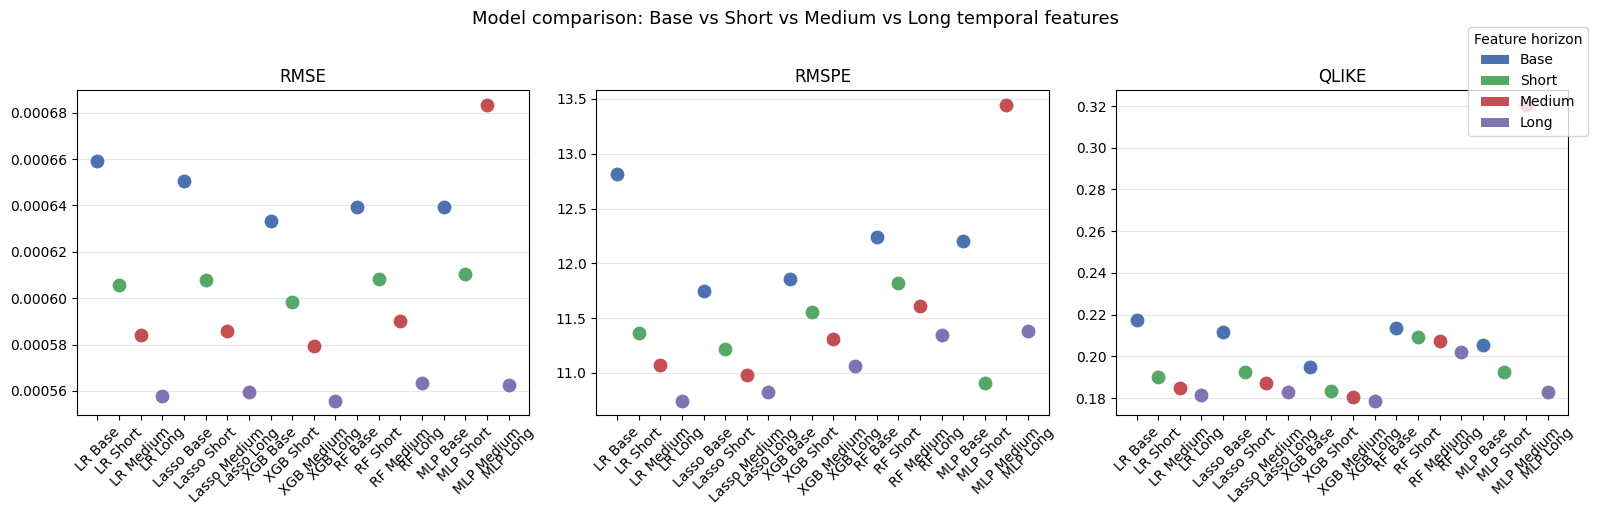


── QLIKE improvement over Base (negative = better) ──

  Linear Regression
    LR Short           Δ QLIKE = -0.027376  ✓ better
    LR Medium          Δ QLIKE = -0.032763  ✓ better
    LR Long            Δ QLIKE = -0.036175  ✓ better

  Lasso
    Lasso Short        Δ QLIKE = -0.019149  ✓ better
    Lasso Medium       Δ QLIKE = -0.024614  ✓ better
    Lasso Long         Δ QLIKE = -0.028625  ✓ better

  XGBoost
    XGB Short          Δ QLIKE = -0.011734  ✓ better
    XGB Medium         Δ QLIKE = -0.014738  ✓ better
    XGB Long           Δ QLIKE = -0.016322  ✓ better

  Random Forest
    RF Short           Δ QLIKE = -0.004271  ✓ better
    RF Medium          Δ QLIKE = -0.006477  ✓ better
    RF Long            Δ QLIKE = -0.011791  ✓ better

  MLP
    MLP Short          Δ QLIKE = -0.012873  ✓ better
    MLP Medium         Δ QLIKE = +0.114945  ✗ worse
    MLP Long           Δ QLIKE = -0.022797  ✓ better


In [ ]:

res_df = pd.DataFrame([
    {'Model': k, 'RMSE': v['rmse'], 'RMSPE': v['rmspe'], 'QLIKE': v['qlike']}
    for k, v in results.items()
])

print('═' * 62)
print(f'  {"Model":<18}  {"RMSE":>10}  {"RMSPE":>10}  {"QLIKE":>10}')
print('─' * 62)

groups = [
    ('Linear Regression', ['LR Base', 'LR Short', 'LR Medium', 'LR Long']),
    ('Lasso',             ['Lasso Base', 'Lasso Short', 'Lasso Medium', 'Lasso Long']),
    ('XGBoost',           ['XGB Base', 'XGB Short', 'XGB Medium', 'XGB Long']),
    ('Random Forest',     ['RF Base', 'RF Short', 'RF Medium', 'RF Long']),
    ('MLP',               ['MLP Base', 'MLP Short', 'MLP Medium', 'MLP Long']),
]

for group_name, model_keys in groups:
    print(f'\n  {group_name}')
    for key in model_keys:
        if key in results:
            r = results[key]
            print(f'  {key:<18}  {r["rmse"]:>10.6f}  {r["rmspe"]:>10.6f}  {r["qlike"]:>10.6f}')

print('\n' + '═' * 62)

best_rmse  = res_df.loc[res_df['RMSE'].idxmin(),  'Model']
best_rmspe = res_df.loc[res_df['RMSPE'].idxmin(), 'Model']
best_qlike = res_df.loc[res_df['QLIKE'].idxmin(), 'Model']
print(f'  Best RMSE  : {best_rmse}')
print(f'  Best RMSPE : {best_rmspe}')
print(f'  Best QLIKE : {best_qlike}')


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {
    'Base': '#4C72B0', 'Short': '#55A868', 'Medium': '#C44E52', 'Long': '#8172B2'
}

for ax, metric in zip(axes, ['RMSE', 'RMSPE', 'QLIKE']):
    for group_name, model_keys in groups:
        for key in model_keys:
            if key in results:
                horizon = key.split()[-1]  
                model   = key.split()[0]   
                val     = results[key][metric.lower()]
                ax.scatter(key, val, color=colors.get(horizon, 'grey'),
                           label=horizon, s=80, zorder=3)

    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)


from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=h) for h, c in colors.items()]
fig.legend(handles=legend_elements, title='Feature horizon',
           loc='upper right', bbox_to_anchor=(1.0, 1.0))

plt.suptitle('Model comparison: Base vs Short vs Medium vs Long temporal features',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


print('\n── QLIKE improvement over Base (negative = better) ──')
for group_name, model_keys in groups:
    base_key = model_keys[0]
    if base_key not in results:
        continue
    base_qlike = results[base_key]['qlike']
    print(f'\n  {group_name}')
    for key in model_keys[1:]:
        if key in results:
            delta = results[key]['qlike'] - base_qlike
            direction = '✓ better' if delta < 0 else '✗ worse'
            print(f'    {key:<18} Δ QLIKE = {delta:+.6f}  {direction}')

## Cell 18 = EwMA 

- predics the next bucket's volatility using an exponentialy weighted average of past square retruens 
- IT DOESN"T TRAIN IT IS RECURSIVE 

In [ ]:


def ewma_volatility(df, lam=0.97):
    """
    Compute EWMA volatility forecast for each (stock_id, time_id).
    At bucket t, forecast uses only buckets 1..t — no look-ahead.
    Returns the input df with an added 'ewma_pred' column.
    """
    result_parts = []

    for (stock_id, time_id), grp in df.groupby(['stock_id', 'time_id']):
        grp = grp.sort_values('bucket').reset_index(drop=True)
        rv  = grp['realised_volatility'].values
        var = np.zeros(len(rv))


        var[0] = rv[0] ** 2


        for t in range(1, len(rv)):
            var[t] = lam * var[t-1] + (1 - lam) * rv[t-1] ** 2

        grp = grp.copy()
        grp['ewma_pred'] = np.maximum(np.sqrt(var), EPS)
        result_parts.append(grp)

    return pd.concat(result_parts, ignore_index=True)



print('Tuning EWMA lambda on validation set...')
lambda_grid = [0.90, 0.92, 0.94, 0.96, 0.97, 0.98, 0.99]
best_lam    = None
best_lam_qlike = np.inf

for lam in lambda_grid:
    val_ewma = ewma_volatility(val_df, lam=lam)
    val_ewma = val_ewma[val_ewma['bucket'] > 1]   
    ql = qlike(val_ewma[target].values, val_ewma['ewma_pred'].values)
    print(f'  λ={lam:.2f}  val QLIKE={ql:.6f}')
    if ql < best_lam_qlike:
        best_lam_qlike = ql
        best_lam = lam

print(f'\nBest λ: {best_lam}')


test_ewma = ewma_volatility(test_df, lam=best_lam)
test_ewma = test_ewma[test_ewma['bucket'] > 1]

y_true_ewma = test_ewma[target].values
y_pred_ewma = test_ewma['ewma_pred'].values

res_ewma = {
    'label': 'EWMA',
    'rmse' : rmse(y_true_ewma, y_pred_ewma),
    'rmspe': rmspe(y_true_ewma, y_pred_ewma),
    'qlike': qlike(y_true_ewma, y_pred_ewma),
}
results['EWMA'] = res_ewma

print(f'\n── EWMA (λ={best_lam}) — Test Results ──')
print(f'RMSE  : {res_ewma["rmse"]:.6f}')
print(f'RMSPE : {res_ewma["rmspe"]:.6f}')
print(f'QLIKE : {res_ewma["qlike"]:.6f}')

Tuning EWMA lambda on validation set...
  λ=0.90  val QLIKE=0.266368
  λ=0.92  val QLIKE=0.271590
  λ=0.94  val QLIKE=0.279398
  λ=0.96  val QLIKE=0.292401
  λ=0.97  val QLIKE=0.303058
  λ=0.98  val QLIKE=0.319952
  λ=0.99  val QLIKE=0.353747

Best λ: 0.9

── EWMA (λ=0.9) — Test Results ──
RMSE  : 0.000757
RMSPE : 14.326191
QLIKE : 0.270585


## Cell 19 - HAR-RV

In [ ]:

har_features = ['realised_volatility', 'rv_rollmean5', 'rv_rollmean10']

X_train_har = train_long[har_features].values
y_train_har = train_long[target].values
X_test_har  = test_long[har_features].values
y_test_har  = test_long[target].values

har_model = LinearRegression()
har_model.fit(X_train_har, y_train_har)

y_pred_har = np.maximum(har_model.predict(X_test_har), EPS)

res_har = {
    'label': 'HAR-RV',
    'rmse' : rmse(y_test_har, y_pred_har),
    'rmspe': rmspe(y_test_har, y_pred_har),
    'qlike': qlike(y_test_har, y_pred_har),
}
results['HAR-RV'] = res_har

print('── HAR-RV — Test Results ──')
print(f'RMSE  : {res_har["rmse"]:.6f}')
print(f'RMSPE : {res_har["rmspe"]:.6f}')
print(f'QLIKE : {res_har["qlike"]:.6f}')

print(f'\nCoefficients (economically interpretable):')
print(f'  β0 intercept      : {har_model.intercept_:.6f}')
print(f'  β1 daily   (lag1) : {har_model.coef_[0]:.6f}  ← weight on current bucket rv')
print(f'  β2 weekly  (5bkt) : {har_model.coef_[1]:.6f}  ← weight on 2.5 min average')
print(f'  β3 monthly (10bkt): {har_model.coef_[2]:.6f}  ← weight on 5 min average')
print()
print('Interpretation:')
print('  Positive β1 → current vol predicts next vol (volatility clustering)')
print('  Positive β2 → medium-term trend matters')
print('  Positive β3 → long-term session level anchors the forecast')

── HAR-RV — Test Results ──
RMSE  : 0.000564
RMSPE : 10.354791
QLIKE : 0.184091

Coefficients (economically interpretable):
  β0 intercept      : 0.000076
  β1 daily   (lag1) : 0.168491  ← weight on current bucket rv
  β2 weekly  (5bkt) : 0.157273  ← weight on 2.5 min average
  β3 monthly (10bkt): 0.559798  ← weight on 5 min average

Interpretation:
  Positive β1 → current vol predicts next vol (volatility clustering)
  Positive β2 → medium-term trend matters
  Positive β3 → long-term session level anchors the forecast


## Cell 20 - Sample Weight Helpe r

- Used for cell 21 and cell 22

In [ ]:

def exponential_weights(buckets, half_life=5):
    """
    Assign exponentially decaying weights based on bucket position.
    Most recent bucket in each session gets weight 1.0.
    """
    max_bucket = buckets.max()
    decay      = np.log(2) / half_life
    return np.exp(-decay * (max_bucket - buckets))


def make_sample_weights(df, half_life=5):
    """
    Apply exponential decay weights within each (stock_id, time_id) group.
    Returns a numpy array aligned with df's row order.
    """
    weights = df.groupby(['stock_id', 'time_id'])['bucket'].transform(
        lambda b: exponential_weights(b, half_life=half_life)
    )
    return weights.values



print('Tuning sample weight half_life on validation set (using LR as proxy)...')

half_life_grid = [2, 3, 5, 7, 10]
best_hl        = None
best_hl_qlike  = np.inf

for hl in half_life_grid:
    w_tr = make_sample_weights(train_df, half_life=hl)
    model = LinearRegression()
    model.fit(X_train_base, y_train_base, sample_weight=w_tr)
    y_pred_val = np.maximum(model.predict(X_val_base), EPS)
    ql = qlike(y_val_base, y_pred_val)
    print(f'  half_life={hl:>3}  val QLIKE={ql:.6f}')
    if ql < best_hl_qlike:
        best_hl_qlike = ql
        best_hl = hl

print(f'\nBest half_life: {best_hl}')
print(f'This will be used for all weighted models below.')


w_train_base   = make_sample_weights(train_df,     half_life=best_hl)
w_train_short  = make_sample_weights(train_short,  half_life=best_hl)
w_train_medium = make_sample_weights(train_medium, half_life=best_hl)
w_train_long   = make_sample_weights(train_long,   half_life=best_hl)

print('Sample weights computed for base, short, medium, long training sets.')

Tuning sample weight half_life on validation set (using LR as proxy)...
  half_life=  2  val QLIKE=0.213815
  half_life=  3  val QLIKE=0.213731
  half_life=  5  val QLIKE=0.213729
  half_life=  7  val QLIKE=0.213774
  half_life= 10  val QLIKE=0.213836

Best half_life: 5
This will be used for all weighted models below.
Sample weights computed for base, short, medium, long training sets.


## CELL 21 - Weighted linear Regression 

- across all horizons 


In [ ]:

print(f'Weighted Linear Regression (half_life={best_hl})\n')

for label, X_tr, y_tr, w_tr, X_te, y_te, feats in [
    ('WLR Base',   X_train_base, y_train_base, w_train_base,
                   X_test_base,  y_test_base,  base_features),
    ('WLR Short',  X_train_s,    y_train_s,    w_train_short,
                   X_test_s,     y_test_s,     features_short),
    ('WLR Medium', X_train_m,    y_train_m,    w_train_medium,
                   X_test_m,     y_test_m,     features_medium),
    ('WLR Long',   X_train_l,    y_train_l,    w_train_long,
                   X_test_l,     y_test_l,     features_long),
]:
    model = LinearRegression()
    model.fit(X_tr, y_tr, sample_weight=w_tr)

    res = evaluate(model, X_te, y_te, label)
    results[label] = res


    unweighted_key = label.replace('WLR', 'LR')
    if unweighted_key in results:
        delta = res['qlike'] - results[unweighted_key]['qlike']
        direction = '✓ better' if delta < 0 else '✗ worse'
        delta_str = f'  Δ QLIKE vs unweighted: {delta:+.6f}  {direction}'
    else:
        delta_str = ''

    print(f'── {label} ──')
    print(f'  Features : {len(feats)}')
    print(f'  RMSE  : {res["rmse"]:.6f}')
    print(f'  RMSPE : {res["rmspe"]:.6f}')
    print(f'  QLIKE : {res["qlike"]:.6f}')
    print(delta_str)
    print()

    if label == 'WLR Base':   wlr_base_model   = model
    if label == 'WLR Short':  wlr_short_model  = model
    if label == 'WLR Medium': wlr_medium_model = model
    if label == 'WLR Long':   wlr_long_model   = model

Weighted Linear Regression (half_life=5)

── WLR Base ──
  Features : 7
  RMSE  : 0.000659
  RMSPE : 12.709083
  QLIKE : 0.217086
  Δ QLIKE vs unweighted: -0.000377  ✓ better

── WLR Short ──
  Features : 15
  RMSE  : 0.000606
  RMSPE : 11.272550
  QLIKE : 0.189964
  Δ QLIKE vs unweighted: -0.000123  ✓ better

── WLR Medium ──
  Features : 24
  RMSE  : 0.000584
  RMSPE : 11.008411
  QLIKE : 0.184662
  Δ QLIKE vs unweighted: -0.000038  ✓ better

── WLR Long ──
  Features : 32
  RMSE  : 0.000558
  RMSPE : 10.706089
  QLIKE : 0.181296
  Δ QLIKE vs unweighted: +0.000007  ✗ worse



## Cell 22 - Weighted XGBoost

In [ ]:

print(f'Weighted XGBoost (half_life={best_hl})\n')

for label, X_tr, y_tr, w_tr, X_v, y_v, X_te, y_te, feats in [
    ('WXGB Base',   X_train_base, y_train_base, w_train_base,
                    X_val_base,   y_val_base,
                    X_test_base,  y_test_base,  base_features),
    ('WXGB Short',  X_train_s,    y_train_s,    w_train_short,
                    X_val_s,      y_val_s,
                    X_test_s,     y_test_s,     features_short),
    ('WXGB Medium', X_train_m,    y_train_m,    w_train_medium,
                    X_val_m,      y_val_m,
                    X_test_m,     y_test_m,     features_medium),
    ('WXGB Long',   X_train_l,    y_train_l,    w_train_long,
                    X_val_l,      y_val_l,
                    X_test_l,     y_test_l,     features_long),
]:
    
    try:
        horizon = label.split()[-1].lower()  
        params  = {
            'base':   best_xgb_base,
            'short':  best_xgb_base,    
            'medium': best_xgb_base,    
            'long':   best_xgb_base,   
        }[horizon]
    except Exception:
        params = best_xgb_base

    model = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=seed,
        verbosity=0,
        n_jobs=-1,
        early_stopping_rounds=30,
        n_estimators=1000,
        **{k: v for k, v in params.items() if k != 'n_estimators'},
    )
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_v, y_v)],  
        verbose=False,
    )

    res = evaluate(model, X_te, y_te, label)
    results[label] = res

    unweighted_key = label.replace('WXGB', 'XGB')
    if unweighted_key in results:
        delta = res['qlike'] - results[unweighted_key]['qlike']
        direction = '✓ better' if delta < 0 else '✗ worse'
        delta_str = f'  Δ QLIKE vs unweighted: {delta:+.6f}  {direction}'
    else:
        delta_str = ''

    print(f'── {label} ──')
    print(f'  Features      : {len(feats)}')
    print(f'  Best iteration: {model.best_iteration}')
    print(f'  RMSE  : {res["rmse"]:.6f}')
    print(f'  RMSPE : {res["rmspe"]:.6f}')
    print(f'  QLIKE : {res["qlike"]:.6f}')
    print(delta_str)
    print()

    if label == 'WXGB Base':   wxgb_base_model   = model
    if label == 'WXGB Short':  wxgb_short_model  = model
    if label == 'WXGB Medium': wxgb_medium_model = model
    if label == 'WXGB Long':   wxgb_long_model   = model

Weighted XGBoost (half_life=5)

── WXGB Base ──
  Features      : 7
  Best iteration: 295
  RMSE  : 0.000635
  RMSPE : 11.586244
  QLIKE : 0.195606
  Δ QLIKE vs unweighted: +0.000475  ✗ worse

── WXGB Short ──
  Features      : 15
  Best iteration: 316
  RMSE  : 0.000599
  RMSPE : 11.358274
  QLIKE : 0.183665
  Δ QLIKE vs unweighted: +0.000268  ✗ worse

── WXGB Medium ──
  Features      : 24
  Best iteration: 228
  RMSE  : 0.000580
  RMSPE : 11.153718
  QLIKE : 0.180560
  Δ QLIKE vs unweighted: +0.000167  ✗ worse

── WXGB Long ──
  Features      : 32
  Best iteration: 206
  RMSE  : 0.000556
  RMSPE : 10.980389
  QLIKE : 0.178935
  Δ QLIKE vs unweighted: +0.000126  ✗ worse



In [29]:
if label == 'WXGB Short':  wxgb_short_model  = model
if label == 'WXGB Medium': wxgb_medium_model = model
if label == 'WXGB Long':   wxgb_long_model   = model

## Cell 23 - FUll model comparison

════════════════════════════════════════════════════════════════════
  Model                         RMSE       RMSPE       QLIKE
────────────────────────────────────────────────────────────────────

  Benchmarks
  EWMA                      0.000757   14.326191    0.270585
  HAR-RV                    0.000564   10.354791    0.184091

  Linear Regression
  LR Base                   0.000659   12.814791    0.217463
  LR Short                  0.000606   11.363320    0.190087
  LR Medium                 0.000584   11.071077    0.184700
  LR Long                   0.000558   10.747754    0.181288

  Weighted LR
  WLR Base                  0.000659   12.709083    0.217086
  WLR Short                 0.000606   11.272550    0.189964
  WLR Medium                0.000584   11.008411    0.184662
  WLR Long                  0.000558   10.706089    0.181296

  Lasso
  Lasso Base                0.000650   11.750069    0.211676
  Lasso Short               0.000608   11.222585    0.192527
  Lasso Me

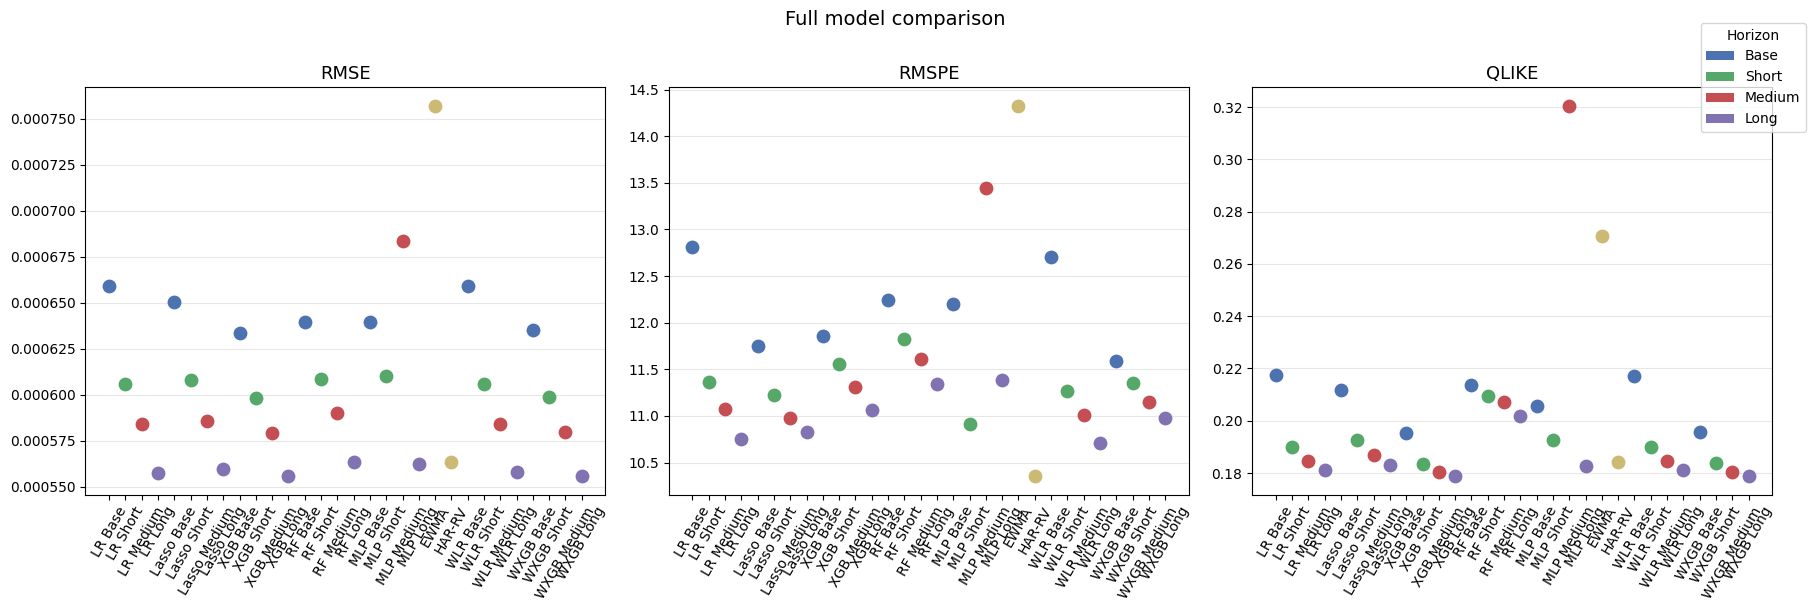


── QLIKE vs EWMA benchmark (QLIKE=0.270585) ──
  LR Base                 Δ=-0.053122  ✓ beats EWMA
  LR Short                Δ=-0.080498  ✓ beats EWMA
  LR Medium               Δ=-0.085885  ✓ beats EWMA
  LR Long                 Δ=-0.089297  ✓ beats EWMA
  Lasso Base              Δ=-0.058909  ✓ beats EWMA
  Lasso Short             Δ=-0.078058  ✓ beats EWMA
  Lasso Medium            Δ=-0.083523  ✓ beats EWMA
  Lasso Long              Δ=-0.087534  ✓ beats EWMA
  XGB Base                Δ=-0.075454  ✓ beats EWMA
  XGB Short               Δ=-0.087188  ✓ beats EWMA
  XGB Medium              Δ=-0.090192  ✓ beats EWMA
  XGB Long                Δ=-0.091776  ✓ beats EWMA
  RF Base                 Δ=-0.056837  ✓ beats EWMA
  RF Short                Δ=-0.061108  ✓ beats EWMA
  RF Medium               Δ=-0.063314  ✓ beats EWMA
  RF Long                 Δ=-0.068628  ✓ beats EWMA
  MLP Base                Δ=-0.065079  ✓ beats EWMA
  MLP Short               Δ=-0.077952  ✓ beats EWMA
  MLP Medium    

In [ ]:


print('═' * 68)
print(f'  {"Model":<22}  {"RMSE":>10}  {"RMSPE":>10}  {"QLIKE":>10}')
print('─' * 68)

groups = [
    ('Benchmarks', [
        'EWMA', 'HAR-RV',
    ]),
    ('Linear Regression', [
        'LR Base', 'LR Short', 'LR Medium', 'LR Long',
    ]),
    ('Weighted LR', [
        'WLR Base', 'WLR Short', 'WLR Medium', 'WLR Long',
    ]),
    ('Lasso', [
        'Lasso Base', 'Lasso Short', 'Lasso Medium', 'Lasso Long',
    ]),
    ('XGBoost', [
        'XGB Base', 'XGB Short', 'XGB Medium', 'XGB Long',
    ]),
    ('Weighted XGBoost', [
        'WXGB Base', 'WXGB Short', 'WXGB Medium', 'WXGB Long',
    ]),
    ('Random Forest', [
        'RF Base', 'RF Short', 'RF Medium', 'RF Long',
    ]),
    ('MLP', [
        'MLP Base', 'MLP Short', 'MLP Medium', 'MLP Long',
    ]),
]

for group_name, model_keys in groups:
    print(f'\n  {group_name}')
    for key in model_keys:
        if key in results:
            r = results[key]
            print(f'  {key:<22}  {r["rmse"]:>10.6f}  {r["rmspe"]:>10.6f}  {r["qlike"]:>10.6f}')

print('\n' + '═' * 68)


res_df = pd.DataFrame([
    {'Model': k, 'RMSE': v['rmse'], 'RMSPE': v['rmspe'], 'QLIKE': v['qlike']}
    for k, v in results.items()
])
print(f'  Best RMSE  : {res_df.loc[res_df["RMSE"].idxmin(),  "Model"]}')
print(f'  Best RMSPE : {res_df.loc[res_df["RMSPE"].idxmin(), "Model"]}')
print(f'  Best QLIKE : {res_df.loc[res_df["QLIKE"].idxmin(), "Model"]}')


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {
    'Base': '#4C72B0', 'Short': '#55A868',
    'Medium': '#C44E52', 'Long': '#8172B2',
    None: '#CCB974',    
}

for ax, metric in zip(axes, ['rmse', 'rmspe', 'qlike']):
    for key, val in results.items():

        parts   = key.split()
        horizon = parts[-1] if parts[-1] in colors else None
        color   = colors[horizon]
        ax.scatter(key, val[metric], color=color, s=80, zorder=3)

    ax.set_title(metric.upper(), fontsize=13)
    ax.tick_params(axis='x', rotation=60)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel('')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=h) for h, c in colors.items() if h]
fig.legend(handles=legend_elements, title='Horizon',
           loc='upper right', bbox_to_anchor=(1.01, 1.0))

plt.suptitle('Full model comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


if 'EWMA' in results:
    ewma_qlike = results['EWMA']['qlike']
    print(f'\n── QLIKE vs EWMA benchmark (QLIKE={ewma_qlike:.6f}) ──')
    for key, val in results.items():
        if key == 'EWMA':
            continue
        delta     = val['qlike'] - ewma_qlike
        direction = '✓ beats EWMA' if delta < 0 else '✗ worse than EWMA'
        print(f'  {key:<22}  Δ={delta:+.6f}  {direction}')

# Testing on Unseen stocks 

In [ ]:

import joblib
import os

os.makedirs('models', exist_ok=True)

models_to_save = {

    'lr_base':          lr_base,
    'lr_short':         lr_short_model,
    'lr_medium':        lr_medium_model,
    'lr_long':          lr_long_model,


    'wlr_base':         wlr_base_model,
    'wlr_short':        wlr_short_model,
    'wlr_medium':       wlr_medium_model,
    'wlr_long':         wlr_long_model,


    'lasso_base':       lasso_final_base,
    'lasso_short':      lasso_short_model,
    'lasso_medium':     lasso_medium_model,
    'lasso_long':       lasso_long_model,


    'xgb_base':         xgb_final_base,
    'xgb_short':        xgb_short_model,
    'xgb_medium':       xgb_medium_model,
    'xgb_long':         xgb_long_model,


    'wxgb_base':        wxgb_base_model,
    'wxgb_short':       wxgb_short_model,
    'wxgb_medium':      wxgb_medium_model,
    'wxgb_long':        wxgb_long_model,


    'rf_base':          rf_final_base,
    'rf_short':         rf_short_model,
    'rf_medium':        rf_medium_model,
    'rf_long':          rf_long_model,


    'mlp_base':         mlp_final_base,
    'mlp_short':        mlp_short_model,
    'mlp_medium':       mlp_medium_model,
    'mlp_long':         mlp_long_model,


    'har_rv':           har_model,
}

print('Saving models...')
failed = []
for name, model in models_to_save.items():
    try:
        path = f'models/{name}.joblib'
        joblib.dump(model, path)
        size_mb = os.path.getsize(path) / 1e6
        print(f'  ✓ {name:<22} → {path}  ({size_mb:.1f} MB)')
    except Exception as e:
        print(f'  ✗ {name:<22} → FAILED: {e}')
        failed.append(name)


joblib.dump(results, 'models/results_dict.joblib')
print(f'  ✓ {"results_dict":<22} → models/results_dict.joblib')

print(f'\n{"─"*50}')
if failed:
    print(f'Failed: {failed}')
    print('These models may not have been fitted yet — check the relevant cells.')
else:
    print(f'All models saved successfully to ./models/')

Saving models...
  ✓ lr_base                → models/lr_base.joblib  (0.0 MB)
  ✓ lr_short               → models/lr_short.joblib  (0.0 MB)
  ✓ lr_medium              → models/lr_medium.joblib  (0.0 MB)
  ✓ lr_long                → models/lr_long.joblib  (0.0 MB)
  ✓ wlr_base               → models/wlr_base.joblib  (0.0 MB)
  ✓ wlr_short              → models/wlr_short.joblib  (0.0 MB)
  ✓ wlr_medium             → models/wlr_medium.joblib  (0.0 MB)
  ✓ wlr_long               → models/wlr_long.joblib  (0.0 MB)
  ✓ lasso_base             → models/lasso_base.joblib  (0.0 MB)
  ✓ lasso_short            → models/lasso_short.joblib  (0.0 MB)
  ✓ lasso_medium           → models/lasso_medium.joblib  (0.0 MB)
  ✓ lasso_long             → models/lasso_long.joblib  (0.0 MB)
  ✓ xgb_base               → models/xgb_base.joblib  (0.5 MB)
  ✓ xgb_short              → models/xgb_short.joblib  (0.7 MB)
  ✓ xgb_medium             → models/xgb_medium.joblib  (0.4 MB)
  ✓ xgb_long               → models/x

In [ ]:

import joblib

model_names = [
    'lr_base', 'lr_short', 'lr_medium', 'lr_long',
    'wlr_base', 'wlr_short', 'wlr_medium', 'wlr_long',
    'lasso_base', 'lasso_short', 'lasso_medium', 'lasso_long',
    'xgb_base', 'xgb_short', 'xgb_medium', 'xgb_long',
    'wxgb_base', 'wxgb_short', 'wxgb_medium', 'wxgb_long',
    'rf_base', 'rf_short', 'rf_medium', 'rf_long',
    'mlp_base', 'mlp_short', 'mlp_medium', 'mlp_long',
    'har_rv',
]

print('Loading models...')
loaded = {}
for name in model_names:
    path = f'models/{name}.joblib'
    try:
        loaded[name] = joblib.load(path)
        print(f'  ✓ {name}')
    except FileNotFoundError:
        print(f'  ✗ {name} — not found')


lr_base          = loaded.get('lr_base')
lr_short_model   = loaded.get('lr_short')
lr_medium_model  = loaded.get('lr_medium')
lr_long_model    = loaded.get('lr_long')

wlr_base_model   = loaded.get('wlr_base')
wlr_short_model  = loaded.get('wlr_short')
wlr_medium_model = loaded.get('wlr_medium')
wlr_long_model   = loaded.get('wlr_long')

lasso_final_base  = loaded.get('lasso_base')
lasso_short_model = loaded.get('lasso_short')
lasso_medium_model= loaded.get('lasso_medium')
lasso_long_model  = loaded.get('lasso_long')

xgb_final_base   = loaded.get('xgb_base')
xgb_short_model  = loaded.get('xgb_short')
xgb_medium_model = loaded.get('xgb_medium')
xgb_long_model   = loaded.get('xgb_long')

wxgb_base_model   = loaded.get('wxgb_base')
wxgb_short_model  = loaded.get('wxgb_short')
wxgb_medium_model = loaded.get('wxgb_medium')
wxgb_long_model   = loaded.get('wxgb_long')

rf_final_base    = loaded.get('rf_base')
rf_short_model   = loaded.get('rf_short')
rf_medium_model  = loaded.get('rf_medium')
rf_long_model    = loaded.get('rf_long')

mlp_final_base   = loaded.get('mlp_base')
mlp_short_model  = loaded.get('mlp_short')
mlp_medium_model = loaded.get('mlp_medium')
mlp_long_model   = loaded.get('mlp_long')

har_model        = loaded.get('har_rv')


results = joblib.load('models/results_dict.joblib')
print(f'\nResults dict loaded: {len(results)} models')
print('All done — ready for evaluation cells.')

Loading models...
  ✓ lr_base
  ✓ lr_short
  ✓ lr_medium
  ✓ lr_long
  ✓ wlr_base
  ✓ wlr_short
  ✓ wlr_medium
  ✓ wlr_long
  ✓ lasso_base
  ✓ lasso_short
  ✓ lasso_medium
  ✓ lasso_long
  ✓ xgb_base
  ✓ xgb_short
  ✓ xgb_medium
  ✓ xgb_long
  ✓ wxgb_base
  ✓ wxgb_short
  ✓ wxgb_medium
  ✓ wxgb_long
  ✓ rf_base
  ✓ rf_short
  ✓ rf_medium
  ✓ rf_long
  ✓ mlp_base
  ✓ mlp_short
  ✓ mlp_medium
  ✓ mlp_long
  ✓ har_rv

Results dict loaded: 30 models
All done — ready for evaluation cells.


Unseen stocks   : 20
Stock IDs       : [np.int64(0), np.int64(17), np.int64(22), np.int64(28), np.int64(30), np.int64(34), np.int64(35), np.int64(38), np.int64(40), np.int64(48), np.int64(60), np.int64(74), np.int64(81), np.int64(84), np.int64(87), np.int64(89), np.int64(93), np.int64(95), np.int64(105), np.int64(111)]
Unique time_ids : 3830
Total rows      : 1,455,115
Buckets present : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Overlap with seen_stocks: set()  (must be empty)

Computing temporal features on unseen data...

Rows available per horizon:
  Base   : 1,455,115
  Short  : 1,301,945
  Medium : 1,148,775
  Long   : 765,850

── Unseen Stock Evaluation ──

  Model                         RMSE       RMSPE       QLIKE     Δ QLIKE
────────────────────────────────────────

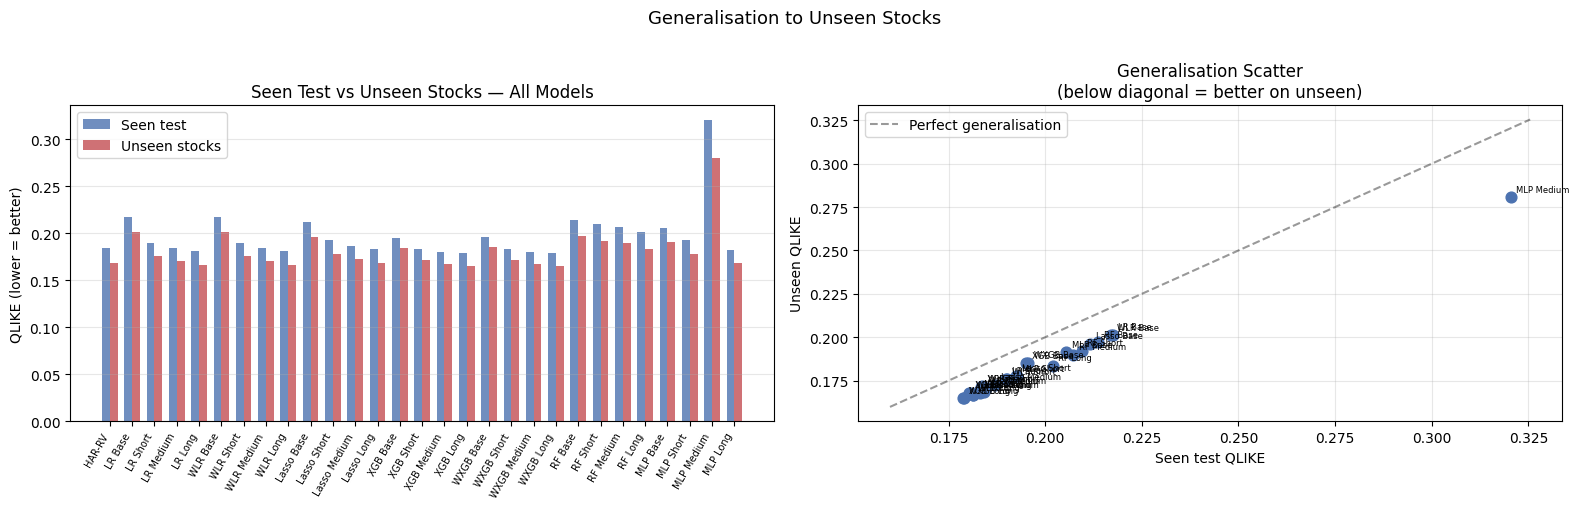

In [ ]:

unseen_data = pd.read_parquet('unseen_data.parquet')
unseen_data = unseen_data.sort_values(
    ['stock_id', 'time_id', 'bucket']
).reset_index(drop=True)

print(f'Unseen stocks   : {unseen_data["stock_id"].nunique()}')
print(f'Stock IDs       : {sorted(unseen_data["stock_id"].unique())}')
print(f'Unique time_ids : {unseen_data["time_id"].nunique()}')
print(f'Total rows      : {len(unseen_data):,}')
print(f'Buckets present : {sorted(unseen_data["bucket"].unique())}')

overlap = set(unseen_data['stock_id'].unique()) & set(seen_stocks)
print(f'Overlap with seen_stocks: {overlap}  (must be empty)')


print('\nComputing temporal features on unseen data...')

unseen_base = unseen_data.dropna(
    subset=base_features + [target]
).reset_index(drop=True)

unseen_short, unseen_medium, unseen_long, _, _, _ = add_temporal_features(
    unseen_data.dropna(subset=base_features + [target])
)

print(f'\nRows available per horizon:')
print(f'  Base   : {len(unseen_base):,}')
print(f'  Short  : {len(unseen_short):,}')
print(f'  Medium : {len(unseen_medium):,}')
print(f'  Long   : {len(unseen_long):,}')


X_unseen_base,   y_unseen_base   = unseen_base[base_features].values,    unseen_base[target].values
X_unseen_short,  y_unseen_short  = unseen_short[features_short].values,  unseen_short[target].values
X_unseen_medium, y_unseen_medium = unseen_medium[features_medium].values, unseen_medium[target].values
X_unseen_long,   y_unseen_long   = unseen_long[features_long].values,    unseen_long[target].values


har_features = ['realised_volatility', 'rv_rollmean5', 'rv_rollmean10']
X_unseen_har = unseen_long[har_features].values
y_unseen_har = unseen_long[target].values


all_unseen_models = [
    
    ('HAR-RV',       har_model,          X_unseen_har,    y_unseen_har),


    ('LR Base',      lr_base,            X_unseen_base,   y_unseen_base),
    ('LR Short',     lr_short_model,     X_unseen_short,  y_unseen_short),
    ('LR Medium',    lr_medium_model,    X_unseen_medium, y_unseen_medium),
    ('LR Long',      lr_long_model,      X_unseen_long,   y_unseen_long),


    ('WLR Base',     wlr_base_model,     X_unseen_base,   y_unseen_base),
    ('WLR Short',    wlr_short_model,    X_unseen_short,  y_unseen_short),
    ('WLR Medium',   wlr_medium_model,   X_unseen_medium, y_unseen_medium),
    ('WLR Long',     wlr_long_model,     X_unseen_long,   y_unseen_long),


    ('Lasso Base',   lasso_final_base,   X_unseen_base,   y_unseen_base),
    ('Lasso Short',  lasso_short_model,  X_unseen_short,  y_unseen_short),
    ('Lasso Medium', lasso_medium_model, X_unseen_medium, y_unseen_medium),
    ('Lasso Long',   lasso_long_model,   X_unseen_long,   y_unseen_long),


    ('XGB Base',     xgb_final_base,     X_unseen_base,   y_unseen_base),
    ('XGB Short',    xgb_short_model,    X_unseen_short,  y_unseen_short),
    ('XGB Medium',   xgb_medium_model,   X_unseen_medium, y_unseen_medium),
    ('XGB Long',     xgb_long_model,     X_unseen_long,   y_unseen_long),


    ('WXGB Base',    wxgb_base_model,    X_unseen_base,   y_unseen_base),
    ('WXGB Short',   wxgb_short_model,   X_unseen_short,  y_unseen_short),
    ('WXGB Medium',  wxgb_medium_model,  X_unseen_medium, y_unseen_medium),
    ('WXGB Long',    wxgb_long_model,    X_unseen_long,   y_unseen_long),


    ('RF Base',      rf_final_base,      X_unseen_base,   y_unseen_base),
    ('RF Short',     rf_short_model,     X_unseen_short,  y_unseen_short),
    ('RF Medium',    rf_medium_model,    X_unseen_medium, y_unseen_medium),
    ('RF Long',      rf_long_model,      X_unseen_long,   y_unseen_long),


    ('MLP Base',     mlp_final_base,     X_unseen_base,   y_unseen_base),
    ('MLP Short',    mlp_short_model,    X_unseen_short,  y_unseen_short),
    ('MLP Medium',   mlp_medium_model,   X_unseen_medium, y_unseen_medium),
    ('MLP Long',     mlp_long_model,     X_unseen_long,   y_unseen_long),
]


unseen_results = {}

print('\n── Unseen Stock Evaluation ──\n')
print(f'  {"Model":<22}  {"RMSE":>10}  {"RMSPE":>10}  {"QLIKE":>10}  {"Δ QLIKE":>10}')
print('─' * 72)

for label, model, X_u, y_u in all_unseen_models:
    y_pred = np.maximum(model.predict(X_u), EPS)
    res = {
        'rmse' : rmse(y_u, y_pred),
        'rmspe': rmspe(y_u, y_pred),
        'qlike': qlike(y_u, y_pred),
    }
    unseen_results[label] = res

    if label in results:
        delta     = res['qlike'] - results[label]['qlike']
        delta_str = f'{delta:>+10.6f}'
    else:
        delta_str = f'{"N/A":>10}'

    print(f'  {label:<22}  {res["rmse"]:>10.6f}  {res["rmspe"]:>10.6f}  {res["qlike"]:>10.6f}  {delta_str}')


print('\n── Top 5 models on unseen stocks (by QLIKE) ──')
unseen_df = pd.DataFrame([
    {'Model': k, 'RMSE': v['rmse'], 'RMSPE': v['rmspe'], 'QLIKE': v['qlike']}
    for k, v in unseen_results.items()
]).sort_values('QLIKE')
print(unseen_df.head(5).to_string(index=False))


best_name  = unseen_df.iloc[0]['Model']
best_model = dict([(l, m) for l, m, _, _ in all_unseen_models])[best_name]

if 'Long' in best_name:
    eval_df = unseen_long;   eval_feats = features_long
elif 'Medium' in best_name:
    eval_df = unseen_medium; eval_feats = features_medium
elif 'Short' in best_name:
    eval_df = unseen_short;  eval_feats = features_short
elif 'HAR' in best_name:
    eval_df = unseen_long;   eval_feats = har_features
else:
    eval_df = unseen_base;   eval_feats = base_features

print(f'\n── Per-stock QLIKE breakdown ({best_name}) ──')
stock_rows = []
for stock_id in sorted(eval_df['stock_id'].unique()):
    sdf = eval_df[eval_df['stock_id'] == stock_id]
    X_s = sdf[eval_feats].values
    y_s = sdf[target].values
    y_p = np.maximum(best_model.predict(X_s), EPS)
    stock_rows.append({
        'stock_id': stock_id,
        'n_rows'  : len(sdf),
        'RMSE'    : rmse(y_s, y_p),
        'RMSPE'   : rmspe(y_s, y_p),
        'QLIKE'   : qlike(y_s, y_p),
    })

stock_res_df = pd.DataFrame(stock_rows).sort_values('QLIKE')
print(stock_res_df.to_string(index=False))


common_models = [k for k in unseen_results if k in results]
seen_qlikes   = [results[k]['qlike']        for k in common_models]
unseen_qlikes = [unseen_results[k]['qlike'] for k in common_models]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


x     = np.arange(len(common_models))
width = 0.35
axes[0].bar(x - width/2, seen_qlikes,   width, label='Seen test',     color='#4C72B0', alpha=0.8)
axes[0].bar(x + width/2, unseen_qlikes, width, label='Unseen stocks', color='#C44E52', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(common_models, rotation=60, ha='right', fontsize=7)
axes[0].set_ylabel('QLIKE (lower = better)')
axes[0].set_title('Seen Test vs Unseen Stocks — All Models')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


axes[1].scatter(seen_qlikes, unseen_qlikes, color='#4C72B0', s=60, zorder=3)
for i, lbl in enumerate(common_models):
    axes[1].annotate(lbl, (seen_qlikes[i], unseen_qlikes[i]),
                     fontsize=6, xytext=(4, 4), textcoords='offset points')
lims = [
    min(min(seen_qlikes), min(unseen_qlikes)) - 0.005,
    max(max(seen_qlikes), max(unseen_qlikes)) + 0.005,
]
axes[1].plot(lims, lims, 'k--', alpha=0.4, label='Perfect generalisation')
axes[1].set_xlabel('Seen test QLIKE')
axes[1].set_ylabel('Unseen QLIKE')
axes[1].set_title('Generalisation Scatter\n(below diagonal = better on unseen)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Generalisation to Unseen Stocks', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
joblib.dump(unseen_results, 'models/unseen_results.joblib')

['models/unseen_results.joblib']

In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("dashboard_outputs", exist_ok=True)

def safe_predict(model, X):
    """
    Predict and clip at EPS.
    The current temporal notebook models predict raw realised volatility,
    not log realised volatility, so we do NOT exponentiate predictions.
    """
    pred = model.predict(X)
    return np.maximum(np.asarray(pred, dtype=float), EPS)


def per_stock_metrics_for_model(
    df,
    model,
    features,
    model_name,
    split_name,
    model_group,
    target_col="target_rv",
):
    """
    Compute RMSE, RMSPE and QLIKE separately for each stock_id.
    This gives each model many observations, which is what a box plot needs.
    """
    rows = []

    needed = ["stock_id", target_col] + features
    d = df.dropna(subset=needed).copy()

    for stock_id, sdf in d.groupby("stock_id"):
        X = sdf[features].values
        y = sdf[target_col].values
        y_pred = safe_predict(model, X)

        rows.append({
            "Split": split_name,
            "Model Group": model_group,
            "Model": model_name,
            "stock_id": stock_id,
            "n_rows": len(sdf),
            "RMSE": rmse(y, y_pred),
            "RMSPE": rmspe(y, y_pred),
            "QLIKE": qlike(y, y_pred),
        })

    return pd.DataFrame(rows)


def build_per_stock_long_results(
    df,
    split_name,
    normal_models,
    weighted_models,
    long_features,
    har_features,
):
    """
    Builds one combined per-stock results table for the long-model dashboard plots.
    """
    pieces = []

    for model_name, model in normal_models.items():
        if model is None:
            print(f"Skipping {model_name}: model object is None")
            continue

        feats = har_features if model_name == "HAR-RV" else long_features

        pieces.append(
            per_stock_metrics_for_model(
                df=df,
                model=model,
                features=feats,
                model_name=model_name,
                split_name=split_name,
                model_group="Normal Long",
                target_col=target,
            )
        )

    for model_name, model in weighted_models.items():
        if model is None:
            print(f"Skipping {model_name}: model object is None")
            continue

        pieces.append(
            per_stock_metrics_for_model(
                df=df,
                model=model,
                features=long_features,
                model_name=model_name,
                split_name=split_name,
                model_group="Weighted Long",
                target_col=target,
            )
        )

    if len(pieces) == 0:
        return pd.DataFrame()

    return pd.concat(pieces, ignore_index=True)

In [ ]:


har_features = ["realised_volatility", "rv_rollmean5", "rv_rollmean10"]

normal_long_models = {
    "LR Long": lr_long_model,
    "Lasso Long": lasso_long_model,
    "XGB Long": xgb_long_model,
    "RF Long": rf_long_model,
    "MLP Long": mlp_long_model,
    "HAR-RV": har_model,
}

weighted_long_models = {
    "WLR Long": wlr_long_model,
    "WXGB Long": wxgb_long_model,
}


seen_per_stock_long = build_per_stock_long_results(
    df=test_long,
    split_name="Seen test",
    normal_models=normal_long_models,
    weighted_models=weighted_long_models,
    long_features=features_long,
    har_features=har_features,
)


unseen_per_stock_long = build_per_stock_long_results(
    df=unseen_long,
    split_name="Unseen anonymous",
    normal_models=normal_long_models,
    weighted_models=weighted_long_models,
    long_features=features_long,
    har_features=har_features,
)

per_stock_long_results = pd.concat(
    [seen_per_stock_long, unseen_per_stock_long],
    ignore_index=True
)


per_stock_long_results.to_csv(
    "dashboard_outputs/per_stock_long_results.csv",
    index=False
)

seen_per_stock_long.to_csv(
    "dashboard_outputs/seen_per_stock_long_results.csv",
    index=False
)

unseen_per_stock_long.to_csv(
    "dashboard_outputs/unseen_per_stock_long_results.csv",
    index=False
)

print("Saved per-stock long-model results:")
print(f"  Combined : dashboard_outputs/per_stock_long_results.csv")
print(f"  Seen     : dashboard_outputs/seen_per_stock_long_results.csv")
print(f"  Unseen   : dashboard_outputs/unseen_per_stock_long_results.csv")
print()
print("Combined shape:", per_stock_long_results.shape)
print()
print(per_stock_long_results.head(12).to_string(index=False))

Saved per-stock long-model results:
  Combined : dashboard_outputs/per_stock_long_results.csv
  Seen     : dashboard_outputs/seen_per_stock_long_results.csv
  Unseen   : dashboard_outputs/unseen_per_stock_long_results.csv

Combined shape: (480, 8)

    Split Model Group   Model  stock_id  n_rows     RMSE     RMSPE    QLIKE
Seen test Normal Long LR Long         5    5750 0.000670 13.175638 0.286161
Seen test Normal Long LR Long         7    5750 0.000375  6.092781 0.205086
Seen test Normal Long LR Long        10    5750 0.000288  1.204899 0.063852
Seen test Normal Long LR Long        13    5750 0.000232  1.851473 0.135195
Seen test Normal Long LR Long        14    5750 0.000239  0.510806 0.050031
Seen test Normal Long LR Long        16    5750 0.000625 15.361075 0.326448
Seen test Normal Long LR Long        18    5750 0.001246 31.584834 0.476664
Seen test Normal Long LR Long        19    5750 0.000397  5.177321 0.201209
Seen test Normal Long LR Long        20    5750 0.000284  1.196851 

In [ ]:


summary_per_stock = (
    per_stock_long_results
    .groupby(["Split", "Model Group", "Model"], as_index=False)
    .agg(
        n_stocks=("stock_id", "nunique"),
        median_RMSE=("RMSE", "median"),
        median_RMSPE=("RMSPE", "median"),
        median_QLIKE=("QLIKE", "median"),
        mean_QLIKE=("QLIKE", "mean"),
    )
    .sort_values(["Split", "Model Group", "median_QLIKE"])
)

print("── Per-stock median performance summary ──")
print(summary_per_stock.to_string(index=False))

summary_per_stock.to_csv(
    "dashboard_outputs/per_stock_long_summary.csv",
    index=False
)

── Per-stock median performance summary ──
           Split   Model Group      Model  n_stocks  median_RMSE  median_RMSPE  median_QLIKE  mean_QLIKE
       Seen test   Normal Long   XGB Long        40     0.000415      4.972068      0.162796    0.178809
       Seen test   Normal Long    LR Long        40     0.000414      5.065587      0.164809    0.181288
       Seen test   Normal Long   MLP Long        40     0.000428      5.185147      0.166372    0.182709
       Seen test   Normal Long     HAR-RV        40     0.000416      4.887693      0.166633    0.184091
       Seen test   Normal Long Lasso Long        40     0.000414      5.150123      0.166704    0.183051
       Seen test   Normal Long    RF Long        40     0.000424      5.748907      0.188538    0.201957
       Seen test Weighted Long  WXGB Long        40     0.000417      4.951046      0.162798    0.178935
       Seen test Weighted Long   WLR Long        40     0.000414      5.045295      0.164812    0.181296
Unseen anony

── Top 10 XGBoost Feature Importance (gain) ──
rv_rollmean10         0.588500
rv_rollmean5          0.292600
rv_rollmean3          0.046900
spread_max            0.014600
realised_volatility   0.009200
log_return_std        0.007200
spread_mean           0.002900
spread_rollmean10     0.002600
rv_rollstd10          0.002600
wap_last              0.002400


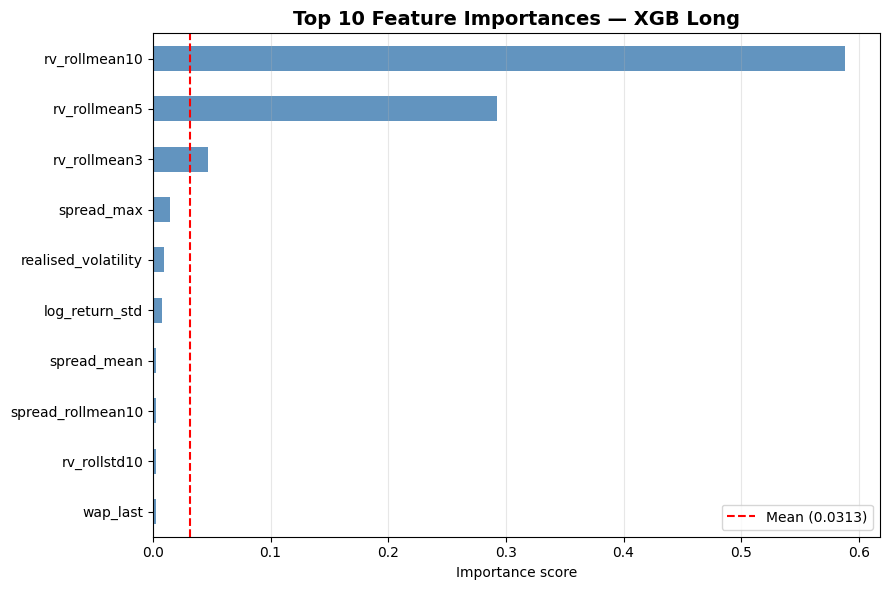

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



xgb_importances = pd.Series(
    xgb_long_model.feature_importances_,
    index=features_long
).sort_values(ascending=False)



top_10_importances = xgb_importances.head(10)

print('── Top 10 XGBoost Feature Importance (gain) ──')
print(top_10_importances.round(4).to_string())



fig, ax = plt.subplots(figsize=(9, 6))

top_10_importances.sort_values().plot(
    kind='barh',
    ax=ax,
    color='steelblue',
    alpha=0.85
)

ax.axvline(
    xgb_importances.mean(),
    color='red',
    linestyle='--',
    label=f'Mean ({xgb_importances.mean():.4f})'
)

ax.set_title(
    'Top 10 Feature Importances — XGB Long',
    fontweight='bold',
    fontsize=14
)

ax.set_xlabel('Importance score')
ax.set_ylabel('')

ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'feature_importance_top10_xgb_long.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

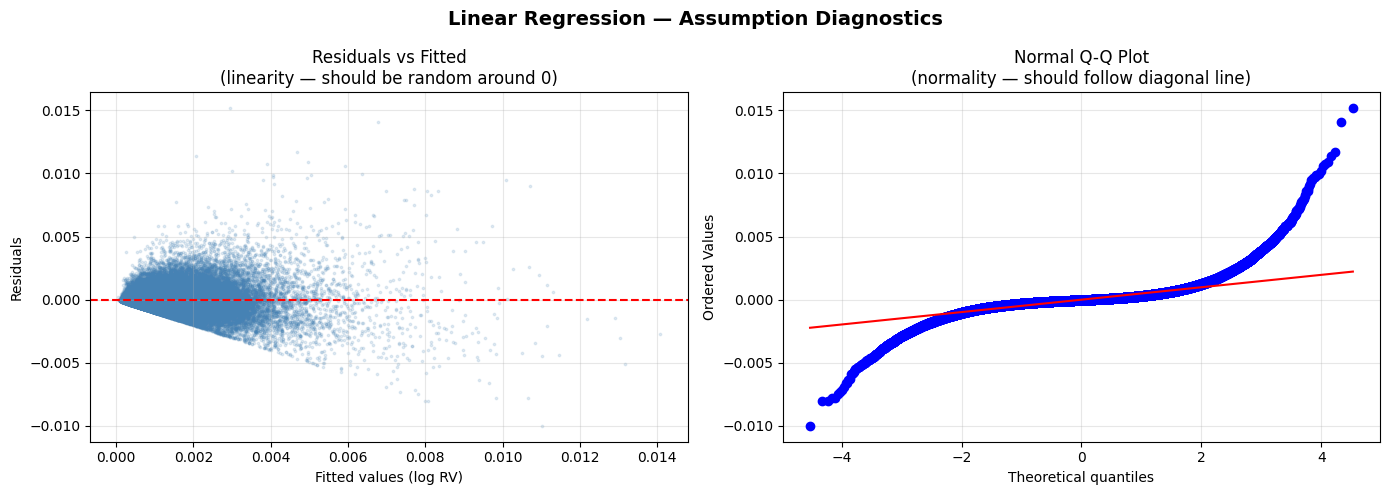

── Assumption Tests ──

Shapiro-Wilk normality test:
  W=0.8028, p=0.000000
  ✗ Residuals NOT normal (α=0.05)

Variance Inflation Factors (VIF):
  VIF > 10 = severe multicollinearity
  VIF > 5  = moderate multicollinearity

            Feature                     VIF
        spread_lag3                     inf
        spread_mean                     inf
realised_volatility                     inf
            rv_lag2                     inf
            rv_lag3                     inf
       rv_rollmean3                     inf
   spread_rollmean3                     inf
        spread_lag2 9007199254740992.000000
           rv_lag10 3002399751580330.500000
            rv_lag5 3002399751580330.500000
       rv_momentum5 1801439850948198.500000
      rv_momentum10 1801439850948198.500000
           rv_delta 1801439850948198.500000
     log_return_std             3238.648808
   spread_rollmean5              430.184111
           wap_last              208.626053
           wap_mean         

In [ ]:

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as LR


y_true    = y_test_l
y_pred    = lr_long_model.predict(X_test_l)
residuals = y_true - y_pred


scaler_diag    = StandardScaler()
X_train_scaled = scaler_diag.fit_transform(X_train_l)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Linear Regression — Assumption Diagnostics', fontsize=14, fontweight='bold')


ax = axes[0]
ax.scatter(y_pred, residuals, alpha=0.15, s=3, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted values (log RV)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted\n(linearity — should be random around 0)')
ax.grid(alpha=0.3)


ax = axes[1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Normal Q-Q Plot\n(normality — should follow diagonal line)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lr_assumption_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


print('── Assumption Tests ──\n')


sample_residuals = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
stat, p = stats.shapiro(sample_residuals)
print(f'Shapiro-Wilk normality test:')
print(f'  W={stat:.4f}, p={p:.6f}')
print(f'  {"✗ Residuals NOT normal" if p < 0.05 else "✓ Residuals normal"} (α=0.05)\n')


sample_idx = np.random.choice(len(X_train_scaled), size=min(10000, len(X_train_scaled)), replace=False)
X_sample   = X_train_scaled[sample_idx]

vif_data = pd.DataFrame({
    'Feature': features_long,
    'VIF':     [variance_inflation_factor(X_sample, i)
                for i in range(X_sample.shape[1])]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factors (VIF):')
print('  VIF > 10 = severe multicollinearity')
print('  VIF > 5  = moderate multicollinearity\n')
print(vif_data.to_string(index=False))

In [ ]:

import pandas as pd
defined_dfs = {name: type(val) for name, val in globals().items() 
               if isinstance(val, pd.DataFrame)}
print(defined_dfs.keys())

dict_keys(['seen_data', 'b19', '_6', 'train_df', 'val_df', 'test_df', 'train_short', 'train_medium', 'train_long', 'val_short', 'val_medium', 'val_long', 'test_short', 'test_medium', 'test_long', 'example', 'full_example', 'coef_df', 'selected', 'imp_df', 'res_df', 'val_ewma', 'test_ewma', 'unseen_data', 'unseen_base', 'unseen_short', 'unseen_medium', 'unseen_long', 'unseen_df', 'eval_df', 'sdf', 'stock_res_df', 'seen_per_stock_long', 'unseen_per_stock_long', 'per_stock_long_results', 'summary_per_stock', 'vif_data'])


In [ ]:

import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go

warnings.filterwarnings("ignore")


EPS = 1e-8

CORE_LONG_MODELS = ["XGB Long", "RF Long", "LR Long", "Lasso Long", "MLP Long"]
CORE_FAMILY_LABELS = {
    "XGB Long":   "XGBoost",
    "RF Long":    "Random Forest",
    "LR Long":    "Linear",
    "Lasso Long": "Lasso",
    "MLP Long":   "MLP",
}



def _hex_to_rgba(hex_color: str, alpha: float) -> str:
    """Convert a 6-digit hex colour to an rgba() string."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def should_use_log_axis(values: pd.Series) -> bool:
    vals = pd.to_numeric(values, errors="coerce")
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) < 2:
        return False
    return bool(vals.max() / max(vals.min(), EPS) > 80)




def load_per_stock_long_results() -> pd.DataFrame:
    """
    Loads per_stock_long_results.csv from dashboard_outputs/.
    This file contains QLIKE/RMSE/RMSPE for each stock, for each model,
    split across 'Seen test' and 'Unseen anonymous' datasets.

    Expected columns: Split, Model Group, Model, stock_id, RMSE, RMSPE, QLIKE
    """

    for path in [
        "dashboard_outputs/per_stock_long_results.csv",
        "per_stock_long_results.csv",
        "dashboard_outputs/seen_per_stock_long_results.csv",
    ]:
        try:
            df = pd.read_csv(path)
            break
        except FileNotFoundError:
            continue
    else:
        print("WARNING: per_stock_long_results.csv not found. Anonymous-stock boxes will be empty.")
        return pd.DataFrame()

    required = {"Split", "Model Group", "Model", "stock_id", "RMSE", "RMSPE", "QLIKE"}
    if not required.issubset(df.columns):
        print(f"WARNING: per_stock_long_results.csv is missing columns: {required - set(df.columns)}")
        return pd.DataFrame()

    for col in ["RMSE", "RMSPE", "QLIKE", "n_rows"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["Model"].isin(CORE_LONG_MODELS)].copy()
    df["Model Group"] = df["Model Group"].replace({
        "Normal Long": "Normal long models",
        "Standard":    "Normal long models",
    })
    df["Split"] = df["Split"].replace({
        "Seen":   "Seen test",
        "Unseen": "Unseen anonymous",
    })
    return df


def load_tech_per_stock_results() -> pd.DataFrame:
    """
    Loads tech_per_stock_all_models.csv produced by 03_Tech_stocks.ipynb.
    Expected columns: stock_id (or stock), Model (or model), RMSE, RMSPE, QLIKE
    """
    for path in [
        "dashboard_outputs/tech_per_stock_all_models.csv",
        "tech_per_stock_all_models.csv",
        "models/tech_per_stock_all_models.csv",
    ]:
        try:
            df = pd.read_csv(path)
            break
        except FileNotFoundError:
            continue
    else:
        print("WARNING: tech_per_stock_all_models.csv not found. Tech-stock boxes will be empty.")
        return pd.DataFrame()

    rename = {
        "model":  "Model",
        "stock":  "stock_id",
        "rmse":   "RMSE",
        "rmspe":  "RMSPE",
        "qlike":  "QLIKE",
    }
    df = df.rename(columns=rename).copy()

    required = {"stock_id", "Model", "RMSE", "RMSPE", "QLIKE"}
    if not required.issubset(df.columns):
        print(f"WARNING: tech_per_stock_all_models.csv is missing columns: {required - set(df.columns)}")
        return pd.DataFrame()

    for col in ["RMSE", "RMSPE", "QLIKE", "n_rows"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["Model"].isin(CORE_LONG_MODELS)].copy()
    df["Dataset"] = "Named tech stocks"
    return df



PER_STOCK_LONG_RESULTS  = load_per_stock_long_results()
TECH_PER_STOCK_RESULTS  = load_tech_per_stock_results()


def generalisability_distribution_df(metric: str = "QLIKE") -> pd.DataFrame:
    rows = []

    if not PER_STOCK_LONG_RESULTS.empty:
        d = PER_STOCK_LONG_RESULTS[
            PER_STOCK_LONG_RESULTS["Model"].isin(CORE_LONG_MODELS)
        ].copy()
        if "Model Group" in d.columns:
            d = d[d["Model Group"].astype(str).eq("Normal long models")].copy()
        keep_cols = [c for c in ["Split", "Model", "stock_id", "n_rows", metric] if c in d.columns]
        d = d[keep_cols].copy()
        d = d.rename(columns={"Split": "Dataset", metric: "Value"})
        rows.append(d)

    if not TECH_PER_STOCK_RESULTS.empty:
        t = TECH_PER_STOCK_RESULTS[TECH_PER_STOCK_RESULTS["Model"].isin(CORE_LONG_MODELS)].copy()
        keep_cols = [c for c in ["Dataset", "Model", "stock_id", "n_rows", metric] if c in t.columns]
        t = t[keep_cols].copy().rename(columns={metric: "Value"})
        rows.append(t)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out["Value"] = pd.to_numeric(out["Value"], errors="coerce")
    out = out.dropna(subset=["Value"])
    out = out[out["Model"].isin(CORE_LONG_MODELS)].copy()
    out["Family"]  = out["Model"].astype(str).map(CORE_FAMILY_LABELS)
    out["Dataset"] = out["Dataset"].replace({
        "Seen":   "Seen test",
        "Unseen": "Unseen anonymous",
    })
    out["Dataset"] = pd.Categorical(
        out["Dataset"],
        categories=["Seen test", "Unseen anonymous", "Named tech stocks"],
        ordered=True,
    )
    out["Model"]  = pd.Categorical(out["Model"],  categories=CORE_LONG_MODELS, ordered=True)
    out["Family"] = pd.Categorical(out["Family"],
                                   categories=[CORE_FAMILY_LABELS[m] for m in CORE_LONG_MODELS],
                                   ordered=True)
    return out.sort_values(["Dataset", "Model"])


def plot_generalisability_box(metric: str = "QLIKE") -> go.Figure:
    """
    Grouped per-stock transfer box plot.
    X-axis = model family; three coloured boxes per family for
    Seen test / Unseen anonymous / Named tech stocks.
    """
    d = generalisability_distribution_df(metric)

    if d.empty:
        fig = go.Figure()
        fig.add_annotation(
            text="Generalisability distributions are unavailable — check that the CSV files are present.",
            x=0.5, y=0.5, showarrow=False, font=dict(size=13, color="#444444"),
        )
        fig.update_layout(template="plotly_white", height=500)
        return fig

    d["Value"]   = pd.to_numeric(d["Value"],   errors="coerce")
    d["Family"]  = d["Family"].astype(str)
    d["Dataset"] = d["Dataset"].astype(str)
    d = d.dropna(subset=["Value"])

    log_scale = should_use_log_axis(d["Value"])

    dataset_order = ["Seen test", "Unseen anonymous", "Named tech stocks"]


    dataset_colors = {
        "Seen test":         "#2166ac",   
        "Unseen anonymous":  "#4dac26",   
        "Named tech stocks": "#d6604d",   
    }
    dataset_offsets = {
        "Seen test":         -0.21,
        "Unseen anonymous":   0.00,
        "Named tech stocks":  0.21,
    }
    family_order  = [CORE_FAMILY_LABELS[m] for m in CORE_LONG_MODELS]
    family_lookup = {f: i for i, f in enumerate(family_order)}

    fig = go.Figure()
    for dataset in dataset_order:
        for family in family_order:
            vals = d.loc[
                d["Dataset"].eq(dataset) & d["Family"].eq(family), "Value"
            ].dropna()
            if vals.empty:
                continue
            x0 = family_lookup[family] + dataset_offsets[dataset]
            fig.add_trace(go.Box(
                x=[x0] * len(vals),
                y=vals,
                name=dataset,
                legendgroup=dataset,
                showlegend=(family == family_order[0]),
                boxpoints=False,
                boxmean=True,
                width=0.16,
                marker_color=dataset_colors[dataset],
                fillcolor=_hex_to_rgba(dataset_colors[dataset], 0.15),
                line=dict(color=dataset_colors[dataset], width=1.5),
                whiskerwidth=0.5,
                hovertemplate=(
                    "Dataset=" + dataset +
                    "<br>Model family=" + family +
                    "<br>" + metric + "=%{y:.6g}<extra></extra>"
                ),
            ))

    fig.update_layout(
        title=dict(
            text=f"Per-stock {metric} distribution by model and evaluation dataset",
            font=dict(size=14, color="#222222"),
            x=0,
            xanchor="left",
        ),
        template="plotly_white",
        height=520,
        margin=dict(l=60, r=20, t=70, b=60),
        boxmode="overlay",
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(family="Arial, sans-serif", size=12, color="#333333"),
        legend=dict(
            title=dict(text="Evaluation dataset", font=dict(size=11)),
            orientation="h",
            yanchor="bottom",
            y=1.01,
            xanchor="right",
            x=1,
            bgcolor="rgba(0,0,0,0)",
            borderwidth=0,
        ),
        xaxis=dict(
            tickmode="array",
            tickvals=list(range(len(family_order))),
            ticktext=family_order,
            title=dict(text="Model family", font=dict(size=12)),
            showgrid=False,
            linecolor="#cccccc",
            linewidth=1,
            tickfont=dict(size=11),
        ),
        yaxis=dict(
            title=dict(text=metric, font=dict(size=12)),
            type="log" if log_scale else "linear",
            gridcolor="#eeeeee",
            linecolor="#cccccc",
            linewidth=1,
            tickfont=dict(size=11),
            zeroline=False,
        ),
    )
    return fig



metric = "QLIKE"   
fig = plot_generalisability_box(metric)
fig.show()

In [ ]:
import json


with open("dashboard_outputs/results.json", "w") as f:
    json.dump(results, f, indent=2)

with open("dashboard_outputs/features_long.json", "w") as f:
    json.dump(features_long, f)

In [ ]:
import json
import pandas as pd


with open("dashboard_outputs/results.json") as f:
    results = json.load(f)


rows = []
for horizon in ['Base', 'Short', 'Medium', 'Long']:
    n_features = {'Base': 7, 'Short': 15, 'Medium': 24, 'Long': 32}[horizon]
    rows.append({
        'Horizon':        horizon,
        'Features':       n_features,
        'XGBoost QLIKE':  results[f'XGB {horizon}']['qlike'],
        'Linear QLIKE':   results[f'LR {horizon}']['qlike'],
        'RF QLIKE':       results[f'RF {horizon}']['qlike'],
        'MLP QLIKE':      results[f'MLP {horizon}']['qlike'],
    })


rows.append({
    'Horizon':        'EWMA',
    'Features':       '—',
    'XGBoost QLIKE':  results['EWMA']['qlike'],
    'Linear QLIKE':   results['EWMA']['qlike'],
    'RF QLIKE':       results['EWMA']['qlike'],
    'MLP QLIKE':      results['EWMA']['qlike'],
})

horizon_df = pd.DataFrame(rows)


print('── Feature Horizon vs QLIKE (Seen test) ──')
print(f'{"Horizon":<10} {"Features":>10} {"XGBoost":>12} {"Linear":>12} {"RF":>12} {"MLP":>12}')
print('─' * 68)
for _, row in horizon_df.iterrows():
    feat = str(row['Features'])
    print(f'{row["Horizon"]:<10} {feat:>10} '
          f'{row["XGBoost QLIKE"]:>12.6f} '
          f'{row["Linear QLIKE"]:>12.6f} '
          f'{row["RF QLIKE"]:>12.6f} '
          f'{row["MLP QLIKE"]:>12.6f}')

── Feature Horizon vs QLIKE (Seen test) ──
Horizon      Features      XGBoost       Linear           RF          MLP
────────────────────────────────────────────────────────────────────
Base                7     0.195131     0.217463     0.213748     0.205506
Short              15     0.183397     0.190087     0.209477     0.192633
Medium             24     0.180393     0.184700     0.207271     0.320451
Long               32     0.178809     0.181288     0.201957     0.182709
EWMA                —     0.270585     0.270585     0.270585     0.270585


── Top 10 XGBoost Feature Importance (gain) ──
rv_rollmean10         0.588500
rv_rollmean5          0.292600
rv_rollmean3          0.046900
spread_max            0.014600
realised_volatility   0.009200
log_return_std        0.007200
spread_mean           0.002900
spread_rollmean10     0.002600
rv_rollstd10          0.002600
wap_last              0.002400


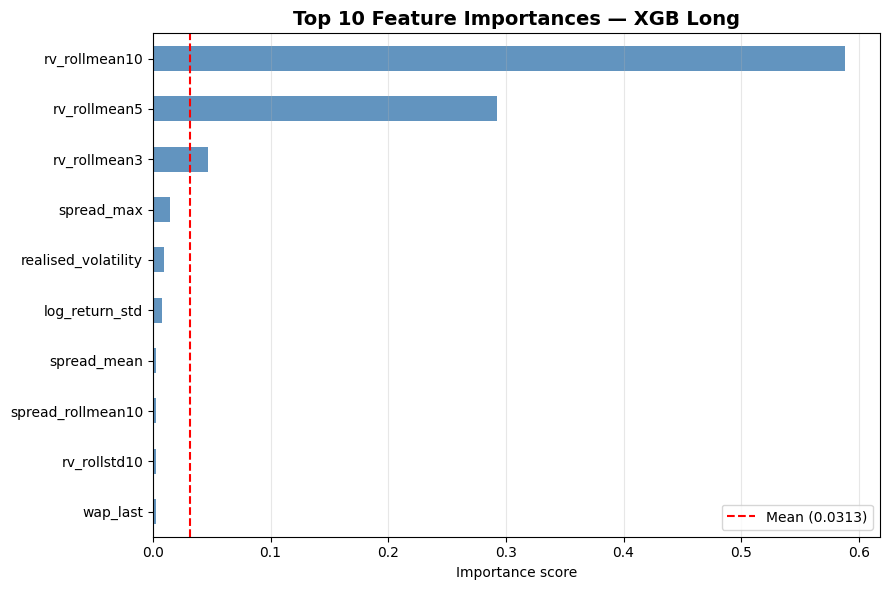

In [ ]:

xgb_long_model = joblib.load("models/xgb_long_model.pkl")

with open("dashboard_outputs/features_long.json") as f:
    features_long = json.load(f)


xgb_importances = pd.Series(
    xgb_long_model.feature_importances_,
    index=features_long
).sort_values(ascending=False)


top_10_importances = xgb_importances.head(10)
print('── Top 10 XGBoost Feature Importance (gain) ──')
print(top_10_importances.round(4).to_string())


fig, ax = plt.subplots(figsize=(9, 6))
top_10_importances.sort_values().plot(
    kind='barh',
    ax=ax,
    color='steelblue',
    alpha=0.85
)
ax.axvline(
    xgb_importances.mean(),
    color='red',
    linestyle='--',
    label=f'Mean ({xgb_importances.mean():.4f})'
)
ax.set_title(
    'Top 10 Feature Importances — XGB Long',
    fontweight='bold',
    fontsize=14
)
ax.set_xlabel('Importance score')
ax.set_ylabel('')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    'feature_importance_top10_xgb_long.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

In [45]:
import json

feature_lists = {
    'base':   base_features,
    'short':  features_short,
    'medium': features_medium,
    'long':   features_long,
}

with open("dashboard_outputs/features_all_horizons.json", "w") as f:
    json.dump(feature_lists, f, indent=2)